In [ ]:
# Libraries imported
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from uwb_dataset import import_from_files
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.fftpack import fft
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import joblib

# Data Preparation / Preprocessing


## Data Exploration

In [66]:
# Load dataset
dataset = import_from_files('../dataset/')
df = pd.DataFrame(dataset)
print(f"Dataset shape: {df.shape}")


Processing file: ../dataset/uwb_dataset_part1.csv
Successfully loaded data from ../dataset/uwb_dataset_part1.csv
Processing file: ../dataset/uwb_dataset_part2.csv
Successfully loaded data from ../dataset/uwb_dataset_part2.csv
Processing file: ../dataset/uwb_dataset_part3.csv
Successfully loaded data from ../dataset/uwb_dataset_part3.csv
Processing file: ../dataset/uwb_dataset_part4.csv
Successfully loaded data from ../dataset/uwb_dataset_part4.csv
Processing file: ../dataset/uwb_dataset_part5.csv
Successfully loaded data from ../dataset/uwb_dataset_part5.csv
Processing file: ../dataset/uwb_dataset_part6.csv
Successfully loaded data from ../dataset/uwb_dataset_part6.csv
Processing file: ../dataset/uwb_dataset_part7.csv
Successfully loaded data from ../dataset/uwb_dataset_part7.csv
Successfully processed 7 files
Dataset shape: (42000, 1031)
Dataset shape: (42000, 1031)


In [67]:
# Add column names
column_names = [
    'NLOS',              # 1 if NLOS, 0 if LOS
    'measured_range',    # Measured range (time of flight) - This will be our target for regression
    'RXPACC',           # received RX preamble symbols
    'FP_AMP1',          # first path amplitude - part1
    'FP_AMP2',          # first path amplitude - part2
    'FP_AMP3',          # first path amplitude - part3
    'STDEV_NOISE',      # standard deviation of noise
    'CIR_PWR',         # total channel impulse response power
    'MAX_NOISE',        # maximum value of noise
    'FP_IDX',          # first path index
    'CH',              # channel number
    'FRAME_LEN',       # length of frame
    'PREAM_LEN',       # preamble length
    'BITRATE',         # bitrate
    'PRFR'             # pulse repetition frequency rate in MHz
]

# Add CIR column names (1016 samples)
cir_columns = [f'CIR_{i}' for i in range(1016)]
column_names.extend(cir_columns)

# Rename DataFrame columns
df.columns = column_names

# Display data types and summary statistics
print("=== Data Types Analysis ===")
print("\nFeature Data Types:")
print(df.dtypes.head(15))

print("\n\nFeature describe:")
print(df.describe())

print("\n\n Shape of total combined dataset:")
print("DataFrame shape:", df.shape)

df.head()

=== Data Types Analysis ===

Feature Data Types:
NLOS              float64
measured_range    float64
RXPACC            float64
FP_AMP1           float64
FP_AMP2           float64
FP_AMP3           float64
STDEV_NOISE       float64
CIR_PWR           float64
MAX_NOISE         float64
FP_IDX            float64
CH                float64
FRAME_LEN         float64
PREAM_LEN         float64
BITRATE           float64
PRFR              float64
dtype: object


Feature describe:
               NLOS  measured_range        RXPACC       FP_AMP1       FP_AMP2  \
count  42000.000000    42000.000000  42000.000000  42000.000000  42000.000000   
mean       0.500000        3.831519    745.654167   8127.521905  11425.259524   
std        0.500006        2.355976      4.505024   5393.330697   6235.434769   
min        0.000000        0.000000    707.000000      7.000000     63.000000   
25%        0.000000        1.810000    744.000000   3573.750000   5322.750000   
50%        0.500000        3.480000    74

,NLOS,measured_range,RXPACC,FP_AMP1,FP_AMP2,FP_AMP3,STDEV_NOISE,CIR_PWR,MAX_NOISE,FP_IDX,...,CIR_1006,CIR_1007,CIR_1008,CIR_1009,CIR_1010,CIR_1011,CIR_1012,CIR_1013,CIR_1014,CIR_1015
0,0.0,3.90,745.0,18712.0,10250.0,11576.0,64.0,11855.0,967.0,611.0,...,279.0,458.0,183.0,158.0,198.0,87.0,296.0,505.0,307.0,0.0
1,0.0,0.66,749.0,11239.0,6313.0,4712.0,64.0,18968.0,1133.0,447.0,...,144.0,334.0,290.0,228.0,187.0,213.0,202.0,89.0,103.0,0.0
2,1.0,7.86,746.0,4355.0,5240.0,3478.0,60.0,14699.0,894.0,723.0,...,32.0,373.0,224.0,174.0,124.0,329.0,207.0,96.0,218.0,0.0
3,1.0,3.48,750.0,8502.0,8416.0,5890.0,76.0,8748.0,1127.0,1024.0,...,252.0,173.0,198.0,160.0,434.0,397.0,290.0,155.0,342.0,256.0
4,0.0,1.19,746.0,17845.0,18095.0,12058.0,68.0,11380.0,1744.0,276.0,...,154.0,209.0,242.0,296.0,87.0,178.0,314.0,247.0,292.0,256.0


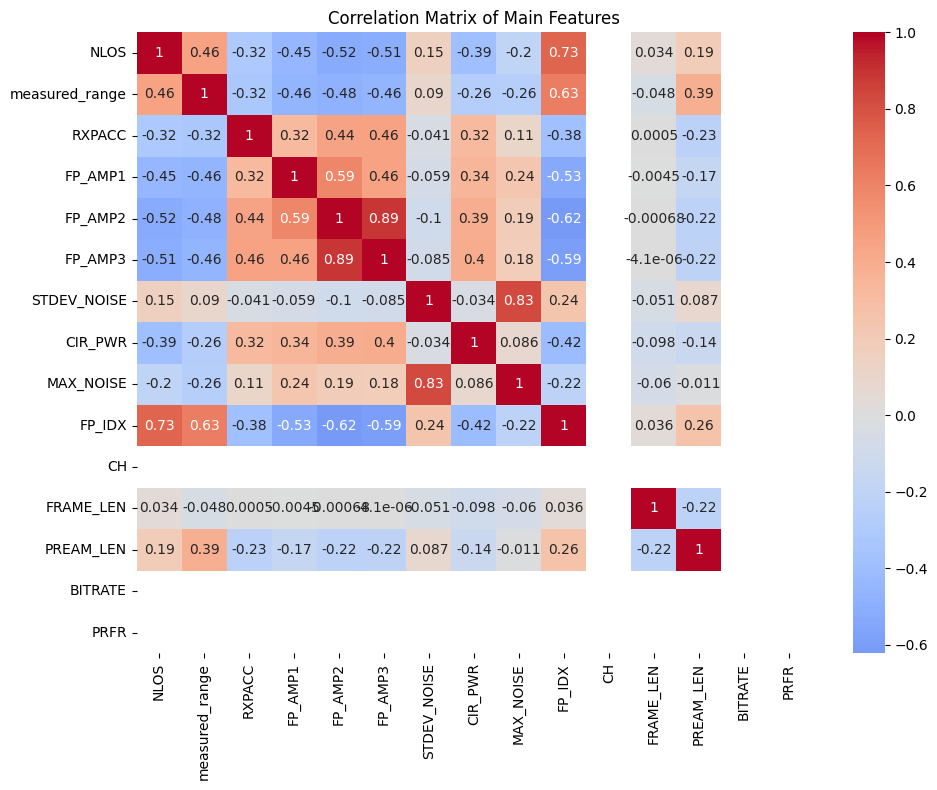

In [68]:
# Main features for correlation analysis
main_features = [
    'NLOS',              # 1 if NLOS, 0 if LOS
    'measured_range',    # Measured range (time of flight) - Our regression target
    'RXPACC',           # received RX preamble symbols
    'FP_AMP1',          # first path amplitude - part1
    'FP_AMP2',          # first path amplitude - part2
    'FP_AMP3',          # first path amplitude - part3
    'STDEV_NOISE',      # standard deviation of noise
    'CIR_PWR',         # total channel impulse response power
    'MAX_NOISE',        # maximum value of noise
    'FP_IDX',          # first path index
    'CH',              # channel number
    'FRAME_LEN',       # length of frame
    'PREAM_LEN',       # preamble length
    'BITRATE',         # bitrate
    'PRFR'             # pulse repetition frequency rate in MHz
]

# Create correlation matrix for main features
plt.figure(figsize=(10, 8))
correlation = df[main_features].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Main Features')
plt.tight_layout()
plt.show()


In [69]:
#distribution plot
cir_columns = [col for col in df.columns if 'CIR_' in col]

# Calculate summary features
df['CIR_mean'] = df[cir_columns].mean(axis=1)
df['CIR_std'] = df[cir_columns].std(axis=1)
df['CIR_max'] = df[cir_columns].max(axis=1)
df['CIR_energy'] = (df[cir_columns]**2).sum(axis=1)

### Visualisations for aggregation of mean,std,max for all CIR cols

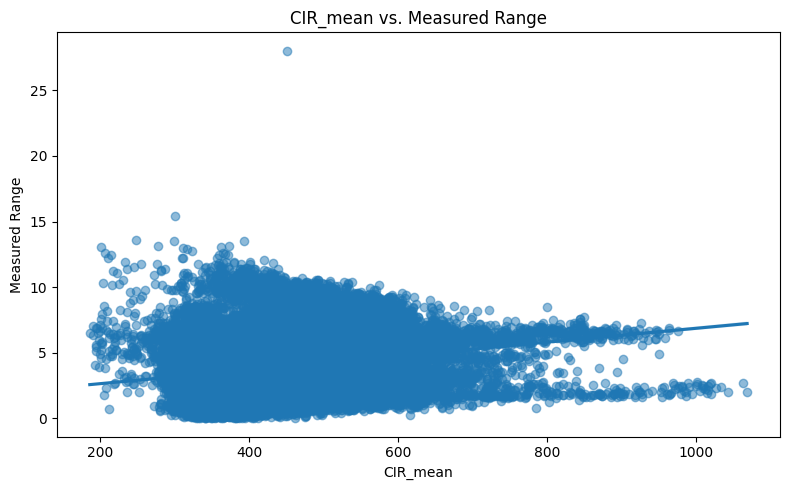

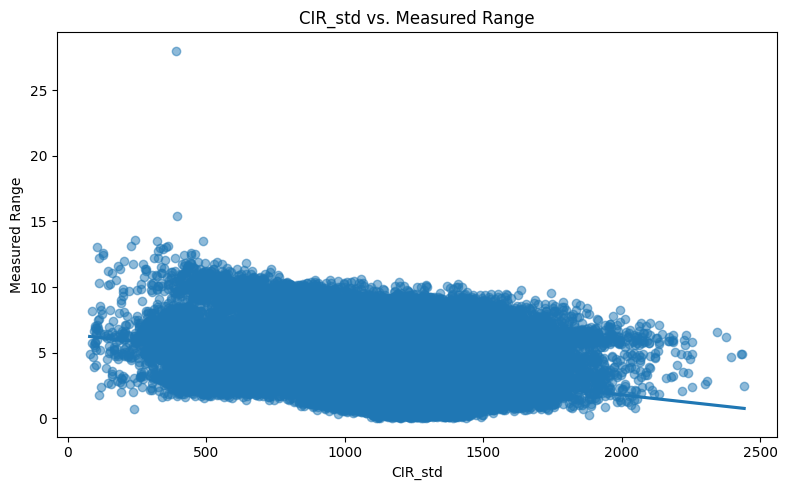

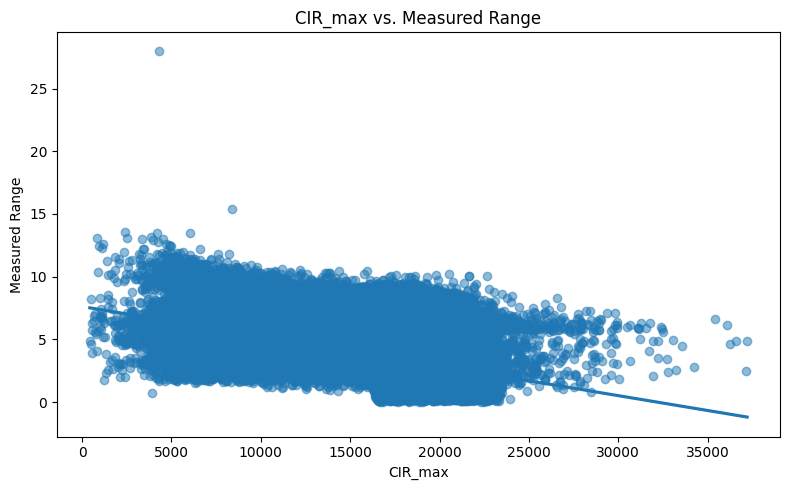

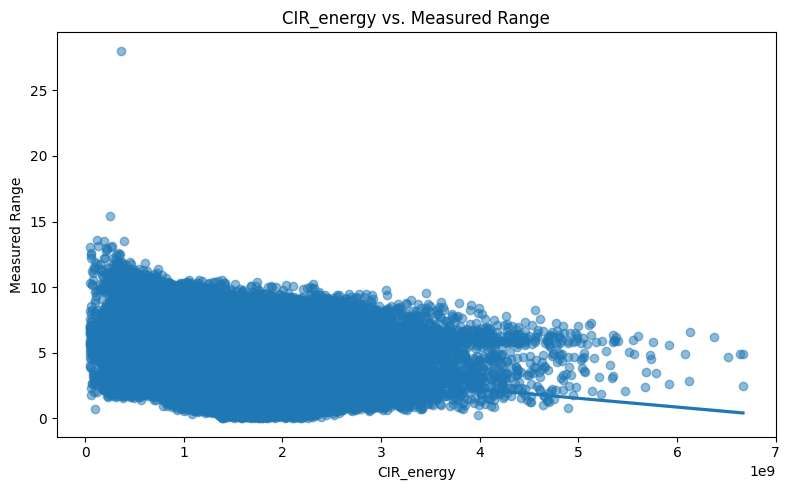

In [70]:
summary_features = ['CIR_mean', 'CIR_std', 'CIR_max', 'CIR_energy']

for feature in summary_features:
    plt.figure(figsize=(8, 5))
    sns.regplot(data=df, x=feature, y='measured_range', scatter_kws={'alpha': 0.5})
    plt.title(f'{feature} vs. Measured Range')
    plt.xlabel(feature)
    plt.ylabel('Measured Range')
    plt.tight_layout()
    plt.show()

### Visualisations for all other features non-CIR cols

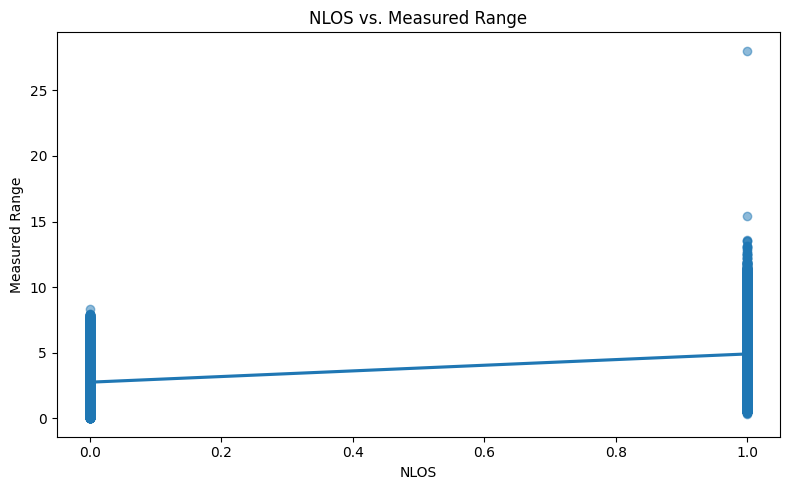

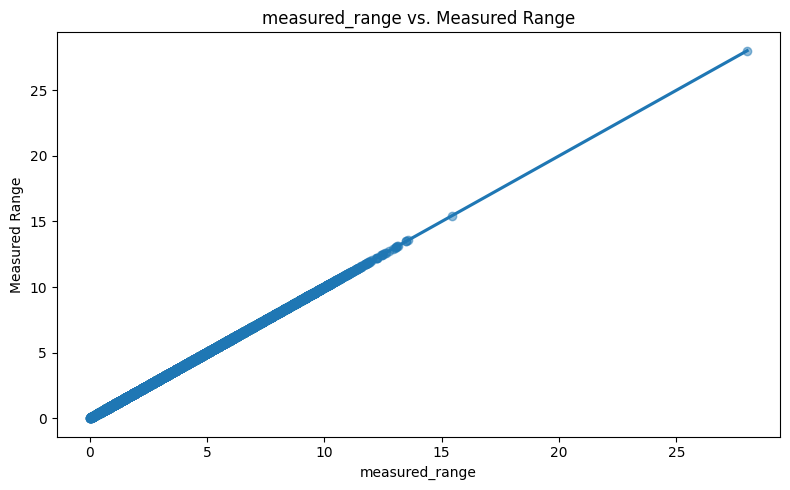

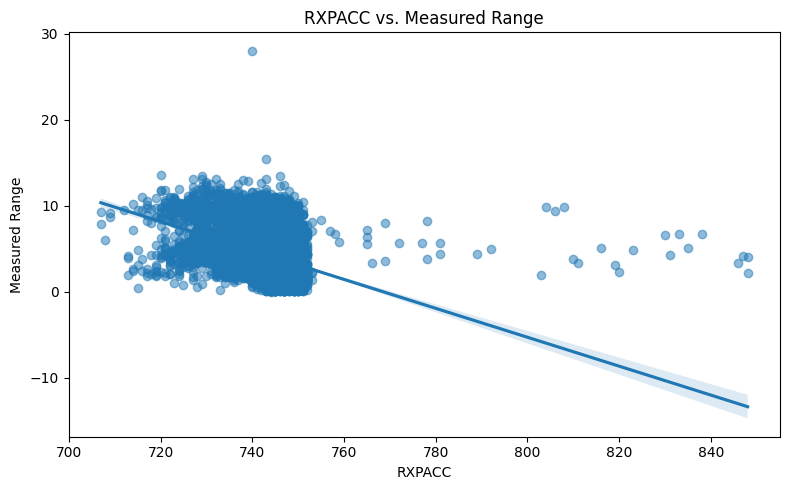

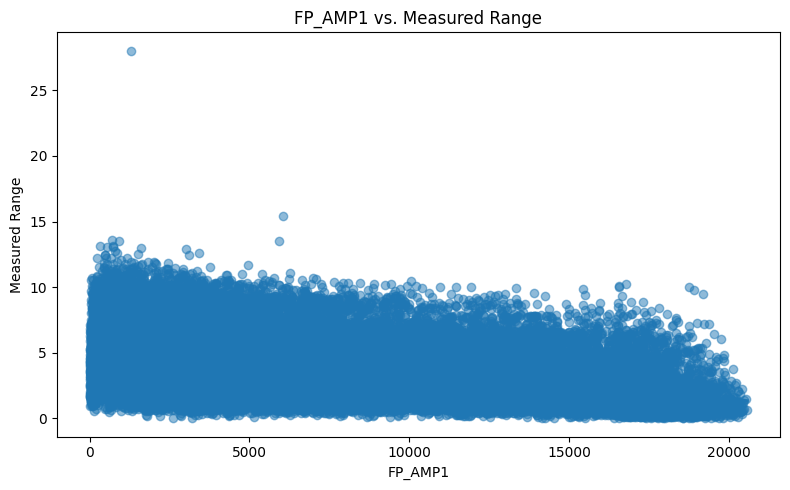

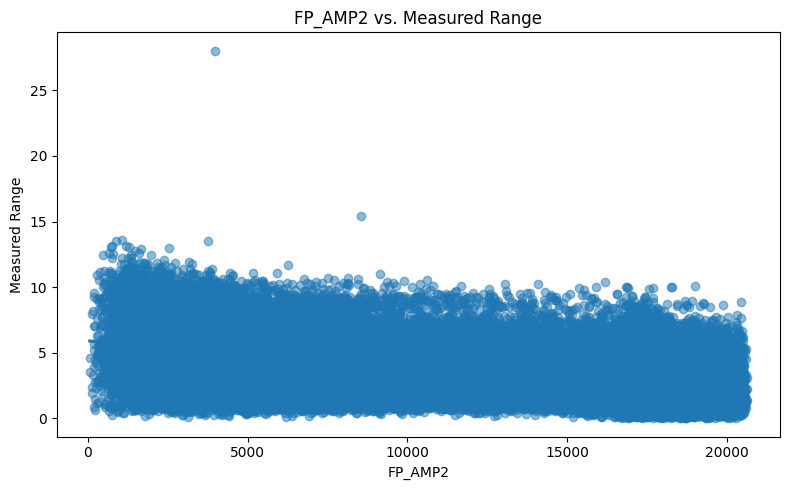

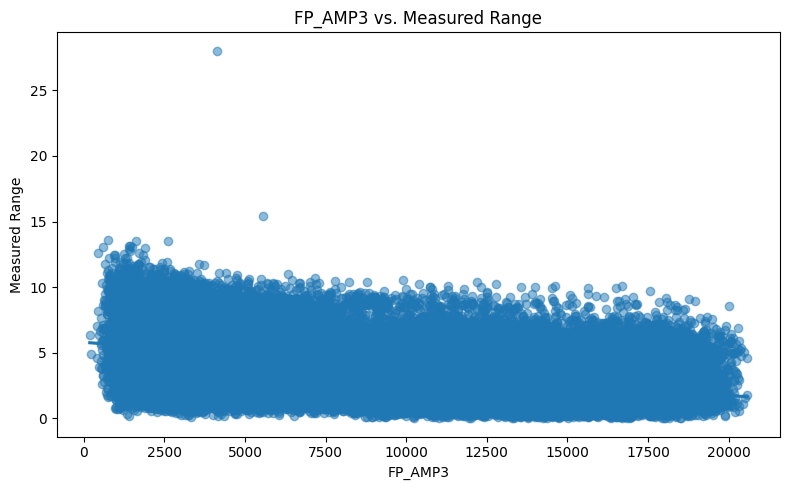

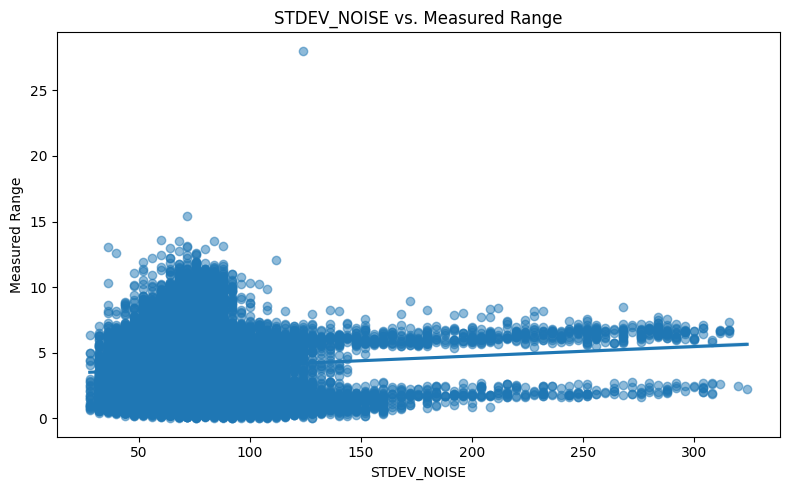

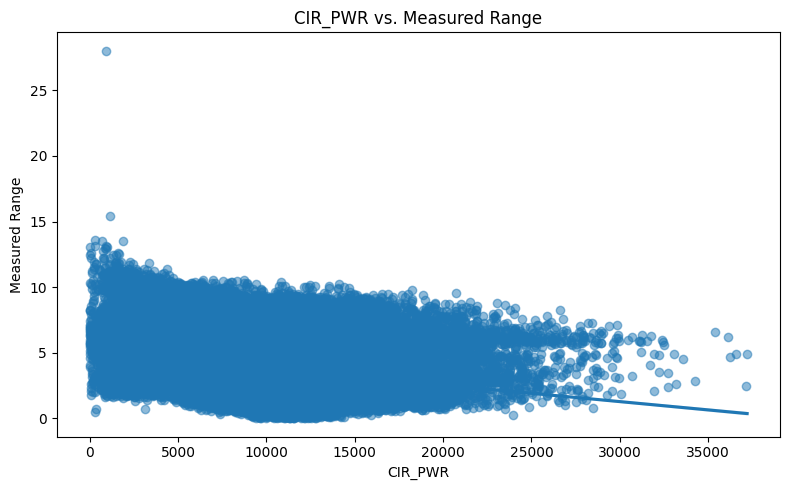

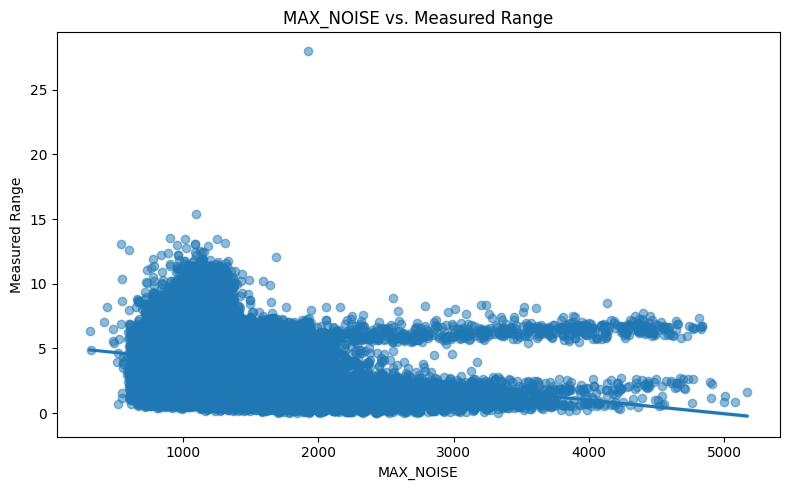

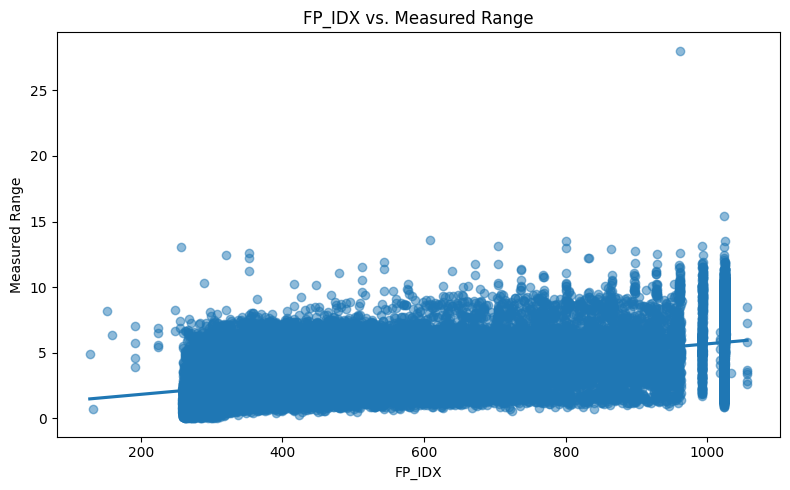

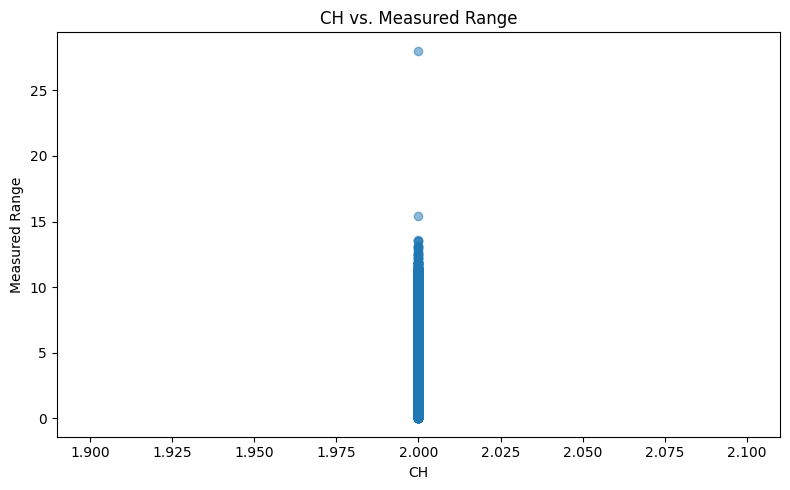

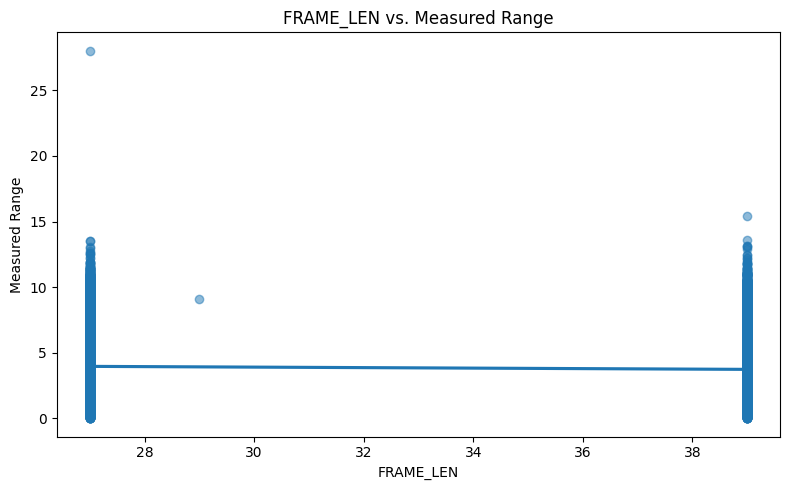

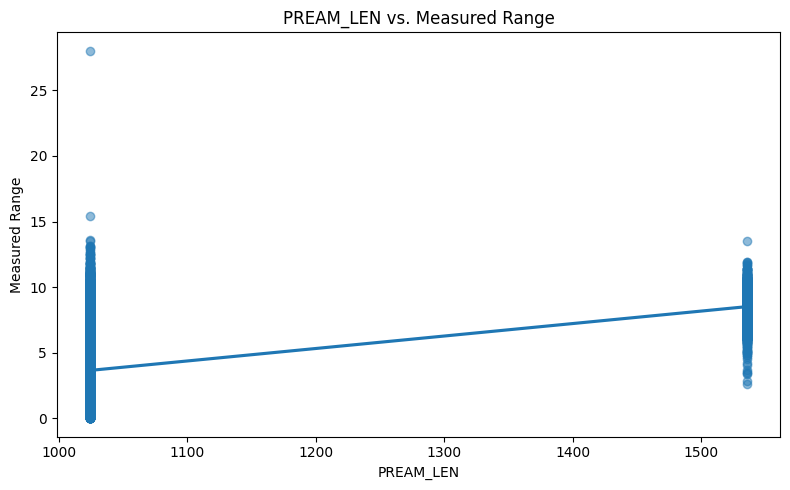

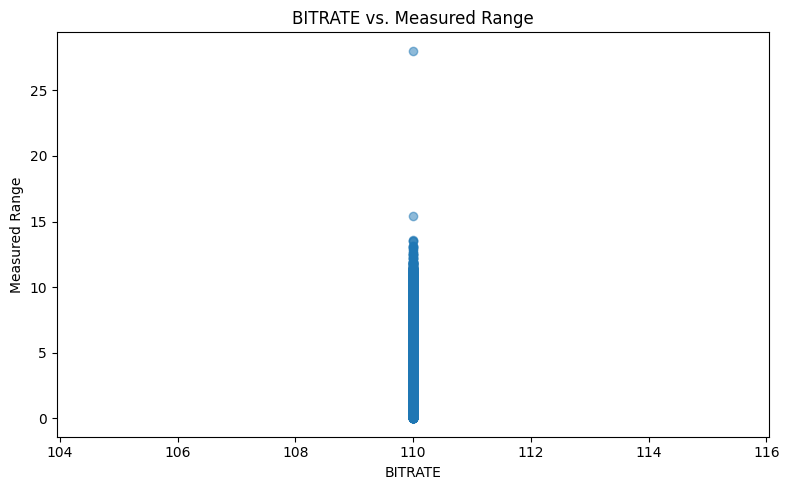

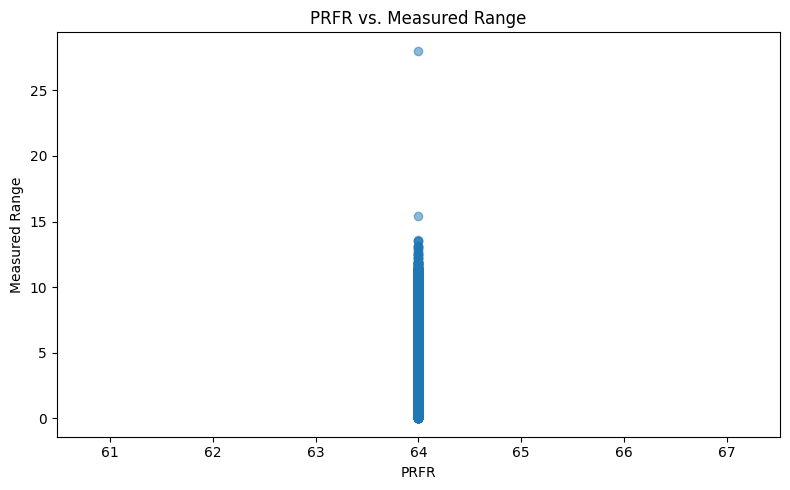

In [71]:
# other_features = ['NLOS', 'FP_AMP1', 'FP_AMP2', 'FP_AMP3', 
#                   'FP_IDX', 'STDEV_NOISE', 'CIR_PWR']

for feature in main_features:
    plt.figure(figsize=(8, 5))
    sns.regplot(data=df, x=feature, y='measured_range', scatter_kws={'alpha': 0.5})
    plt.title(f'{feature} vs. Measured Range')
    plt.xlabel(feature)
    plt.ylabel('Measured Range')
    plt.tight_layout()
    plt.show()

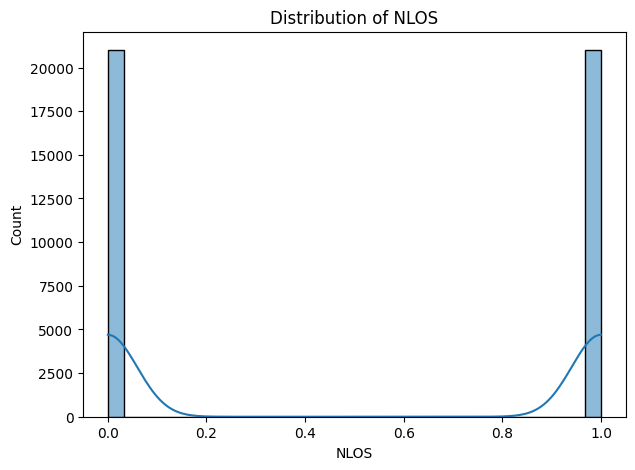

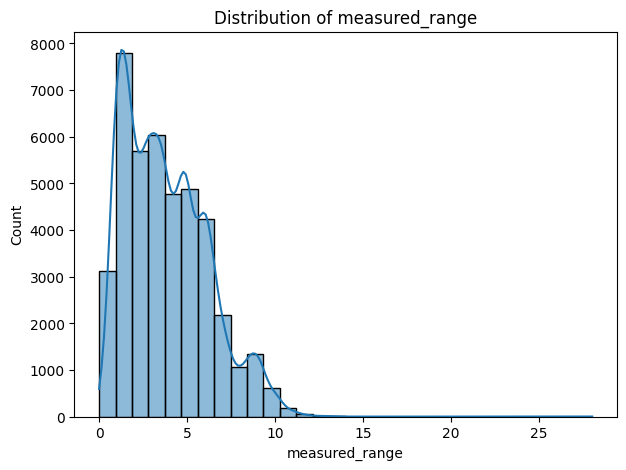

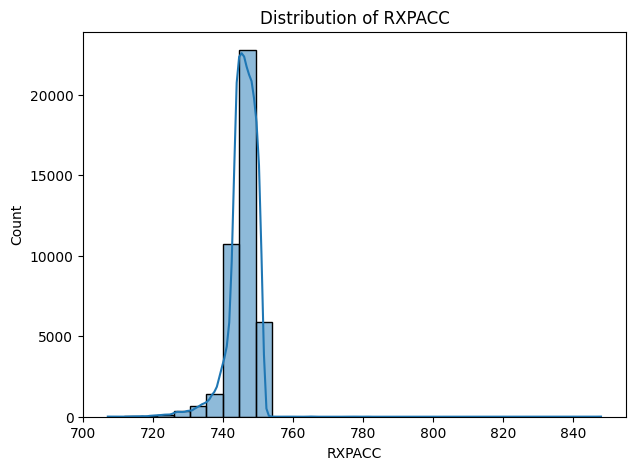

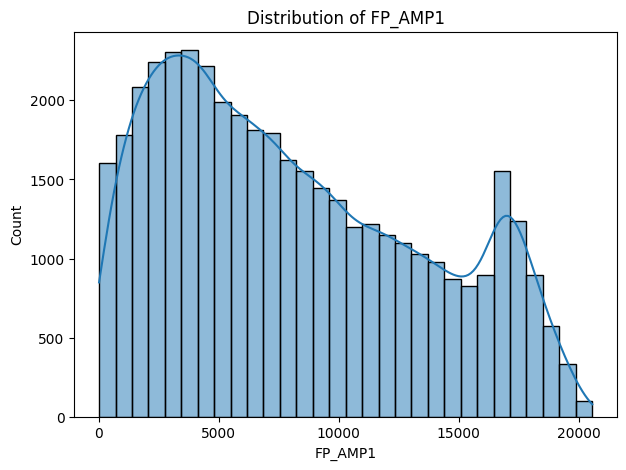

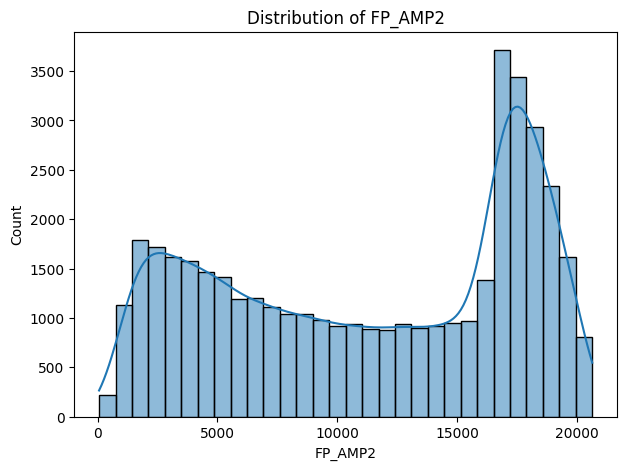

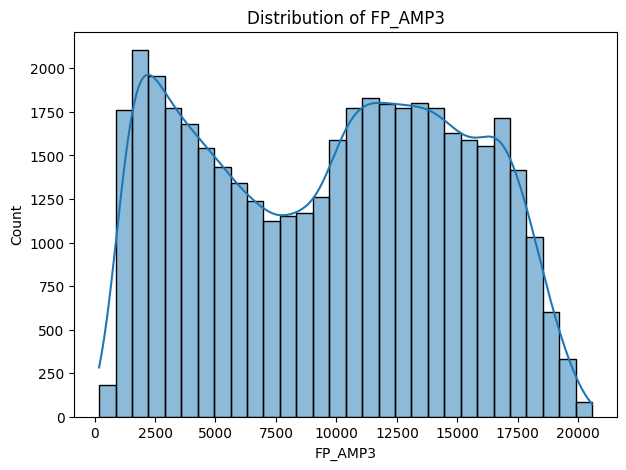

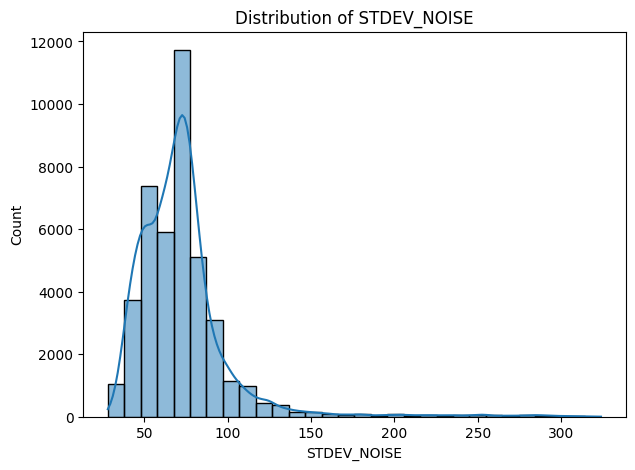

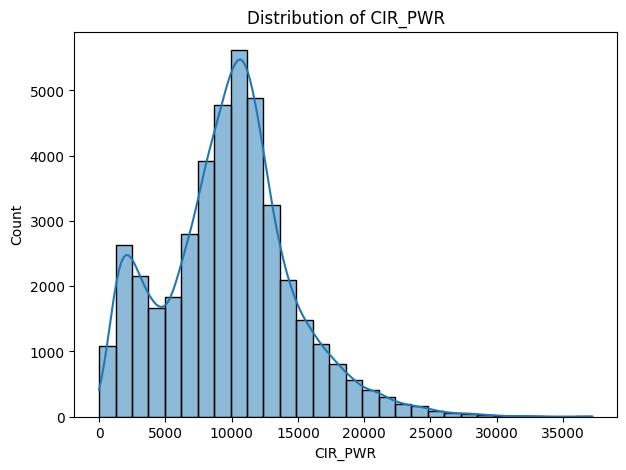

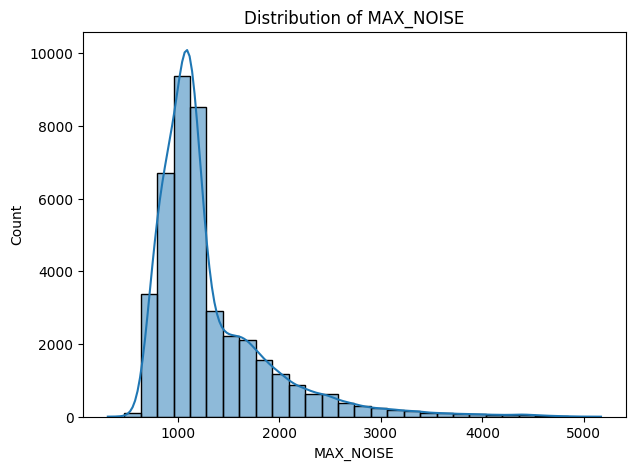

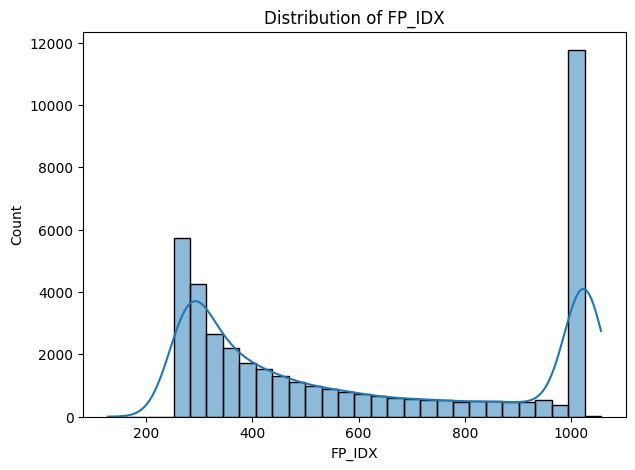

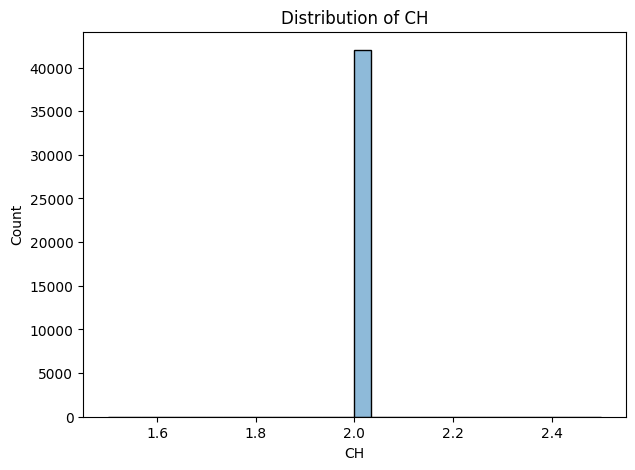

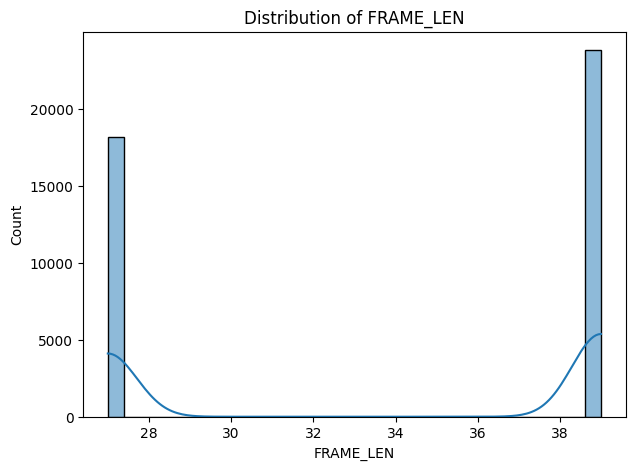

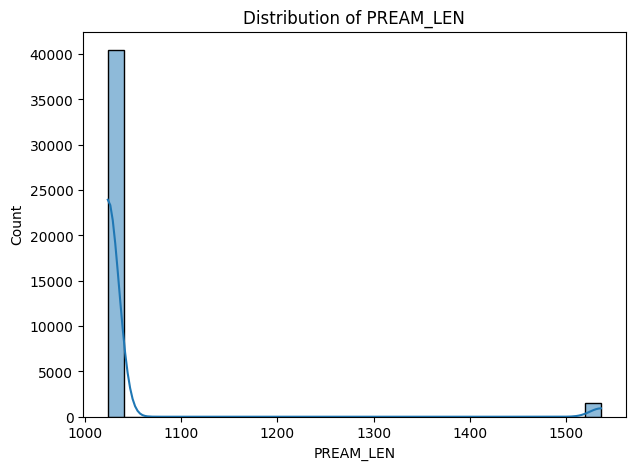

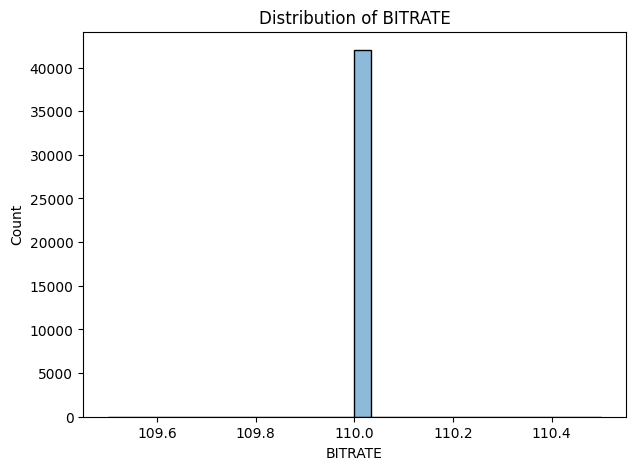

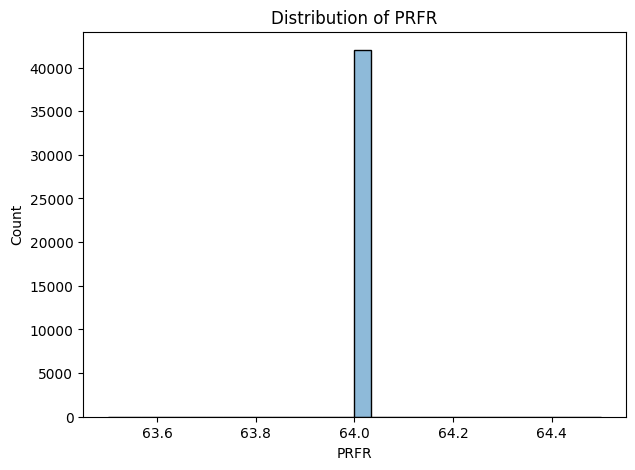

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

for feature in main_features:
    plt.figure(figsize=(7,5))
    sns.histplot(df[feature], kde=True, bins=30)
    plt.title(f"Distribution of {feature}")
    plt.show()


In [11]:
variance = df[main_features].var()
print("Variance for each non-CIR attribute")
print(variance)

Variance for each non-CIR attribute
NLOS              2.500060e-01
measured_range    5.550622e+00
RXPACC            2.029524e+01
FP_AMP1           2.908802e+07
FP_AMP2           3.888065e+07
FP_AMP3           2.864724e+07
STDEV_NOISE       8.596035e+02
CIR_PWR           2.413321e+07
MAX_NOISE         3.392305e+05
FP_IDX            9.411726e+04
CH                0.000000e+00
FRAME_LEN         3.535754e+01
PREAM_LEN         9.358013e+03
BITRATE           0.000000e+00
PRFR              0.000000e+00
dtype: float64


<font color='yellow'>**FINDINGS**</font>
>from this graphs you can tell there are 4 attributes that have constant values regardless of NLOS/LOS; thus most likely uninsightful and can be dropped but let's confirm it with more statistical evidence. The 4 attributes include 
> - CH 
> - BITRATE 
> - PRFR
> - PREAM_LEN
>
>
>  *High Variance*
>   - Captures more variability in data 
>   - More insightful in finding out patterns or making predictions
>
>
> However looking at the variance table you can tell it has a high variance compared to 0/negligible values for the other 3. Thus we will keep PREAM_LEN but remove the other 3 columns

## Data Cleaning

### Removing less important features

In [72]:
# Create a copy of the original DataFrame
df_original = df.copy()

# Define the columns to drop
drop_cols = ['CH', 'BITRATE', 'PRFR']

# Drop the specified columns from the DataFrame
df = df.drop(columns=drop_cols)

# Print the shape of the original and updated DataFrames
print(f"Copy of original df shape: {df_original.shape}")
print(f"Updated dropped shape: {df.shape}")

# Display the column names of the original and updated DataFrames
print("Original DataFrame columns:")
print(df_original.columns.tolist())
print("\nUpdated DataFrame columns:")
print(df.columns.tolist())

Copy of original df shape: (42000, 1035)
Updated dropped shape: (42000, 1032)
Original DataFrame columns:
['NLOS', 'measured_range', 'RXPACC', 'FP_AMP1', 'FP_AMP2', 'FP_AMP3', 'STDEV_NOISE', 'CIR_PWR', 'MAX_NOISE', 'FP_IDX', 'CH', 'FRAME_LEN', 'PREAM_LEN', 'BITRATE', 'PRFR', 'CIR_0', 'CIR_1', 'CIR_2', 'CIR_3', 'CIR_4', 'CIR_5', 'CIR_6', 'CIR_7', 'CIR_8', 'CIR_9', 'CIR_10', 'CIR_11', 'CIR_12', 'CIR_13', 'CIR_14', 'CIR_15', 'CIR_16', 'CIR_17', 'CIR_18', 'CIR_19', 'CIR_20', 'CIR_21', 'CIR_22', 'CIR_23', 'CIR_24', 'CIR_25', 'CIR_26', 'CIR_27', 'CIR_28', 'CIR_29', 'CIR_30', 'CIR_31', 'CIR_32', 'CIR_33', 'CIR_34', 'CIR_35', 'CIR_36', 'CIR_37', 'CIR_38', 'CIR_39', 'CIR_40', 'CIR_41', 'CIR_42', 'CIR_43', 'CIR_44', 'CIR_45', 'CIR_46', 'CIR_47', 'CIR_48', 'CIR_49', 'CIR_50', 'CIR_51', 'CIR_52', 'CIR_53', 'CIR_54', 'CIR_55', 'CIR_56', 'CIR_57', 'CIR_58', 'CIR_59', 'CIR_60', 'CIR_61', 'CIR_62', 'CIR_63', 'CIR_64', 'CIR_65', 'CIR_66', 'CIR_67', 'CIR_68', 'CIR_69', 'CIR_70', 'CIR_71', 'CIR_72', 'CIR

 ### Check for missing values

In [73]:
# check that the categorical data for part 1 is has no other values other than 0/1
print('unique labels in NLOS: ', df['NLOS'].unique())

unique labels in NLOS:  [0. 1.]


In [74]:
# Check for missing values
print('Number of instances = %d' % (df.shape[0]))
print('Number of attributes = %d' % (df.shape[1]))

print('Number of missing values:')
for col in df.columns[:15]:  # Only check main features, not all CIR columns
    print('\t%s: %d' % (col, df[col].isna().sum()))


Number of instances = 42000
Number of attributes = 1032
Number of missing values:
	NLOS: 0
	measured_range: 0
	RXPACC: 0
	FP_AMP1: 0
	FP_AMP2: 0
	FP_AMP3: 0
	STDEV_NOISE: 0
	CIR_PWR: 0
	MAX_NOISE: 0
	FP_IDX: 0
	FRAME_LEN: 0
	PREAM_LEN: 0
	CIR_0: 0
	CIR_1: 0
	CIR_2: 0


### Different dtype from what is expected

In [75]:
#check if the values have anything other than numeric float64 basically
for col in df.columns:
    unique_values = df[col].unique()
    print(f"Unique values in {col}: {unique_values[:10]}")  # Show first 10 unique values

Unique values in NLOS: [0. 1.]
Unique values in measured_range: [3.9  0.66 7.86 3.48 1.19 1.27 0.28 1.23 4.99 1.17]
Unique values in RXPACC: [745. 749. 746. 750. 748. 744. 747. 737. 741. 751.]
Unique values in FP_AMP1: [18712. 11239.  4355.  8502. 17845.  3446. 18991. 14781.  4053. 10153.]
Unique values in FP_AMP2: [10250.  6313.  5240.  8416. 18095. 13680. 19444. 10399.  8174.  7675.]
Unique values in FP_AMP3: [11576.  4712.  3478.  5890. 12058. 11955. 18370. 10136.  5404.  6064.]
Unique values in STDEV_NOISE: [ 64.  60.  76.  68.  92. 148.  40. 100. 108.  44.]
Unique values in CIR_PWR: [11855. 18968. 14699.  8748. 11380. 10256. 13006.  8025.  9956. 11466.]
Unique values in MAX_NOISE: [ 967. 1133.  894. 1127. 1744. 1397. 3904. 1035. 1485. 2487.]
Unique values in FP_IDX: [ 611.  447.  723. 1024.  276.  600.  283.  272.  301.  278.]
Unique values in FRAME_LEN: [39. 27. 29.]
Unique values in PREAM_LEN: [1024. 1536.]
Unique values in CIR_0: [129. 117. 433. 466. 259. 465. 284. 191. 207.  6

### Check for dups

In [76]:
dups = df.duplicated()
dups

0        False
1        False
2        False
3        False
4        False
         ...  
41995    False
41996    False
41997    False
41998    False
41999    False
Length: 42000, dtype: bool

In [17]:
duplicate = df[df.duplicated()]
duplicate

,NLOS,measured_range,RXPACC,FP_AMP1,FP_AMP2,FP_AMP3,STDEV_NOISE,CIR_PWR,MAX_NOISE,FP_IDX,...,CIR_1010,CIR_1011,CIR_1012,CIR_1013,CIR_1014,CIR_1015,CIR_mean,CIR_std,CIR_max,CIR_energy


In [19]:
column_names = df.columns.tolist()
print("Column names:")
for name in column_names:
    print(name)

Column names:
NLOS
measured_range
RXPACC
FP_AMP1
FP_AMP2
FP_AMP3
STDEV_NOISE
CIR_PWR
MAX_NOISE
FP_IDX
FRAME_LEN
PREAM_LEN
CIR_0
CIR_1
CIR_2
CIR_3
CIR_4
CIR_5
CIR_6
CIR_7
CIR_8
CIR_9
CIR_10
CIR_11
CIR_12
CIR_13
CIR_14
CIR_15
CIR_16
CIR_17
CIR_18
CIR_19
CIR_20
CIR_21
CIR_22
CIR_23
CIR_24
CIR_25
CIR_26
CIR_27
CIR_28
CIR_29
CIR_30
CIR_31
CIR_32
CIR_33
CIR_34
CIR_35
CIR_36
CIR_37
CIR_38
CIR_39
CIR_40
CIR_41
CIR_42
CIR_43
CIR_44
CIR_45
CIR_46
CIR_47
CIR_48
CIR_49
CIR_50
CIR_51
CIR_52
CIR_53
CIR_54
CIR_55
CIR_56
CIR_57
CIR_58
CIR_59
CIR_60
CIR_61
CIR_62
CIR_63
CIR_64
CIR_65
CIR_66
CIR_67
CIR_68
CIR_69
CIR_70
CIR_71
CIR_72
CIR_73
CIR_74
CIR_75
CIR_76
CIR_77
CIR_78
CIR_79
CIR_80
CIR_81
CIR_82
CIR_83
CIR_84
CIR_85
CIR_86
CIR_87
CIR_88
CIR_89
CIR_90
CIR_91
CIR_92
CIR_93
CIR_94
CIR_95
CIR_96
CIR_97
CIR_98
CIR_99
CIR_100
CIR_101
CIR_102
CIR_103
CIR_104
CIR_105
CIR_106
CIR_107
CIR_108
CIR_109
CIR_110
CIR_111
CIR_112
CIR_113
CIR_114
CIR_115
CIR_116
CIR_117
CIR_118
CIR_119
CIR_120
CIR_121
CIR_122
CIR_

### Remove Outliers 

In [79]:
from scipy.stats import zscore

# Define features to check for outliers (Exclude CIR)
outlier_features = ['measured_range', 'FP_IDX', 'FP_AMP1', 'FP_AMP2', 'FP_AMP3', 'STDEV_NOISE', 'CIR_PWR', 'MAX_NOISE']

# Compute Z-score
z_scores = df[outlier_features].apply(zscore)

# Keep only rows where all values are within 3 standard deviations
df_cleaned = df[(z_scores > -3).all(axis=1) & (z_scores <= 3).all(axis=1)]

print(f"Original dataset shape: {df.shape}")
print(f"Dataset shape after outlier removal: {df_cleaned.shape}")

Original dataset shape: (42000, 1032)
Dataset shape after outlier removal: (40473, 1032)


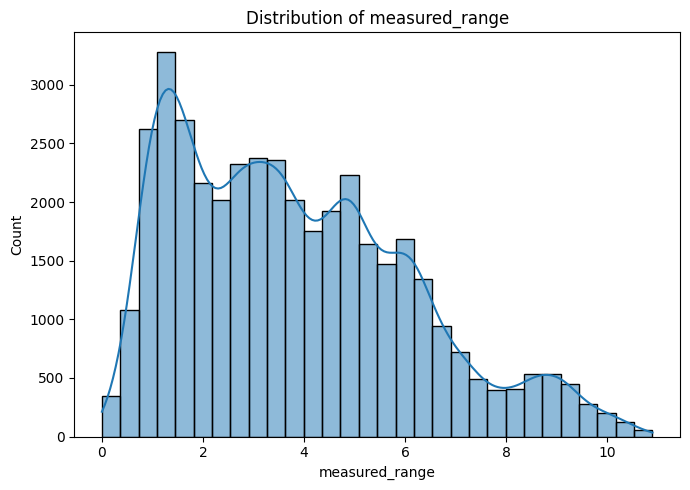

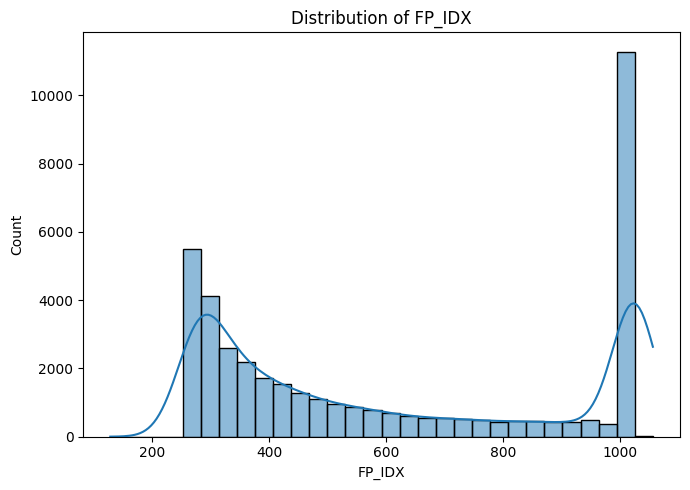

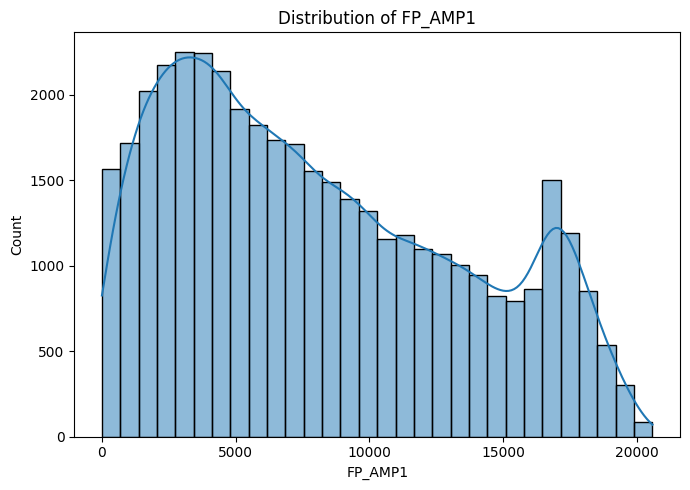

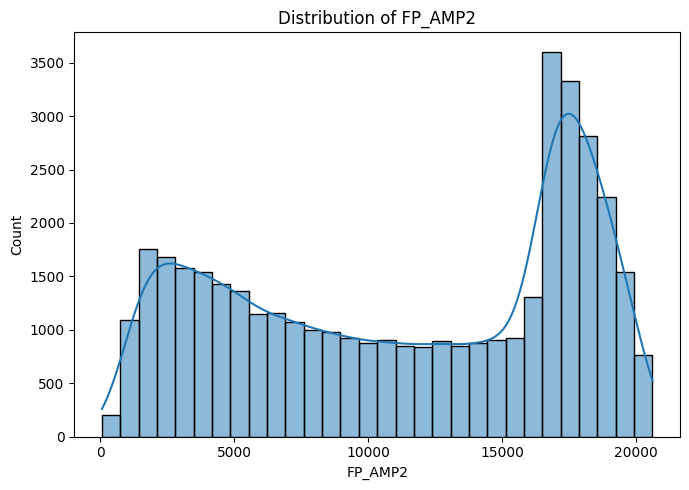

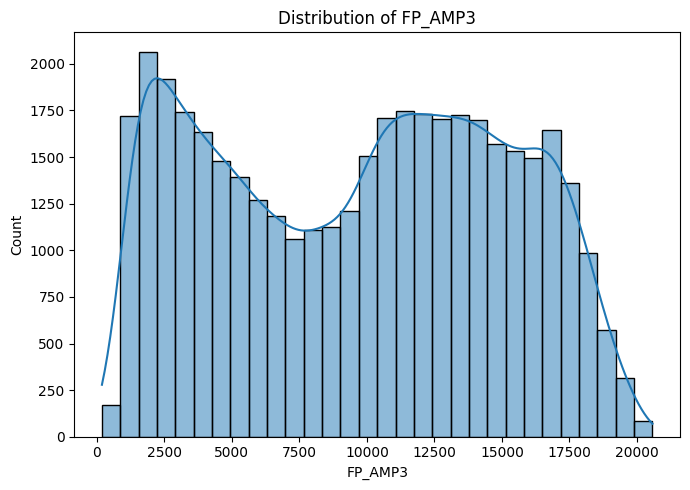

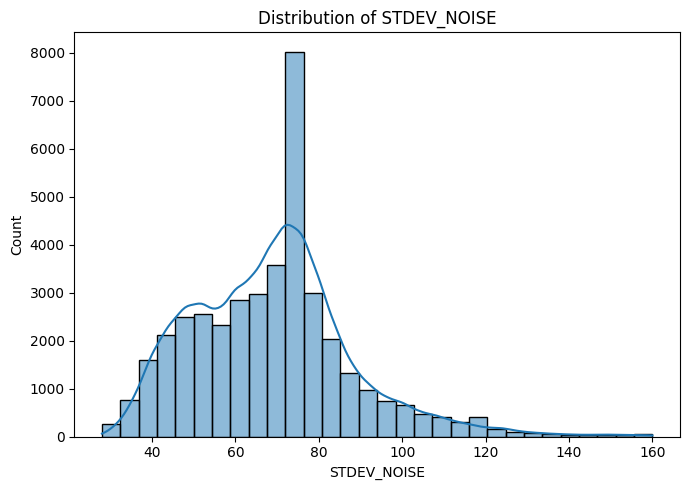

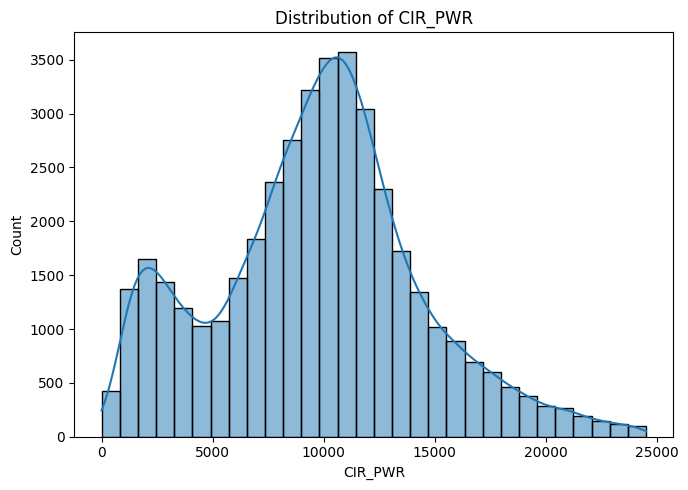

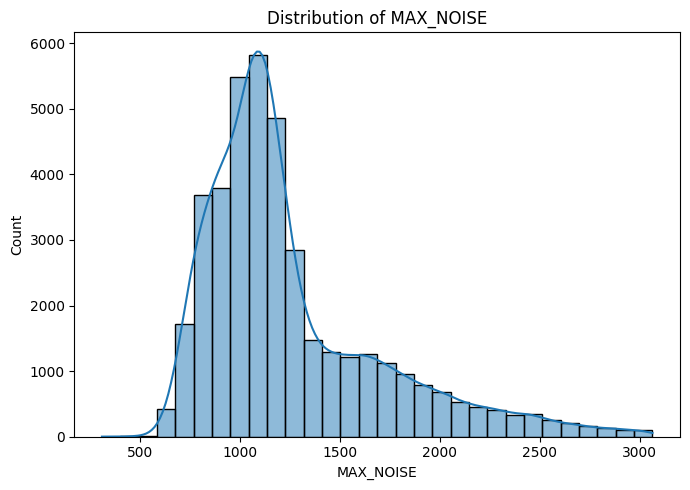

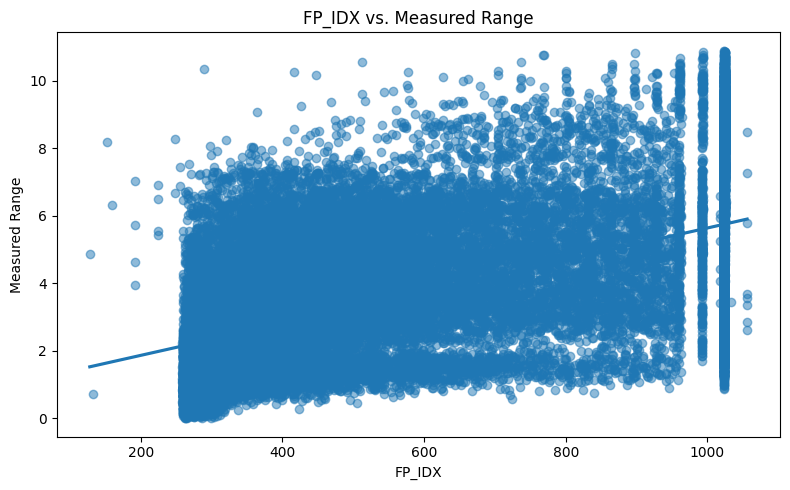

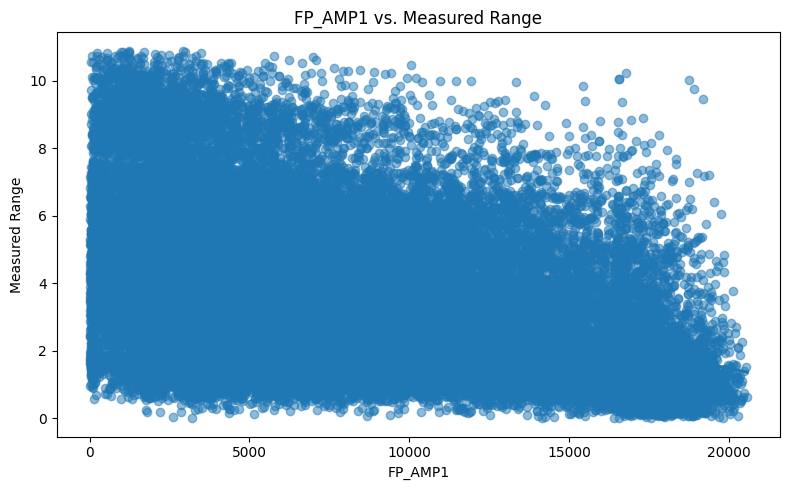

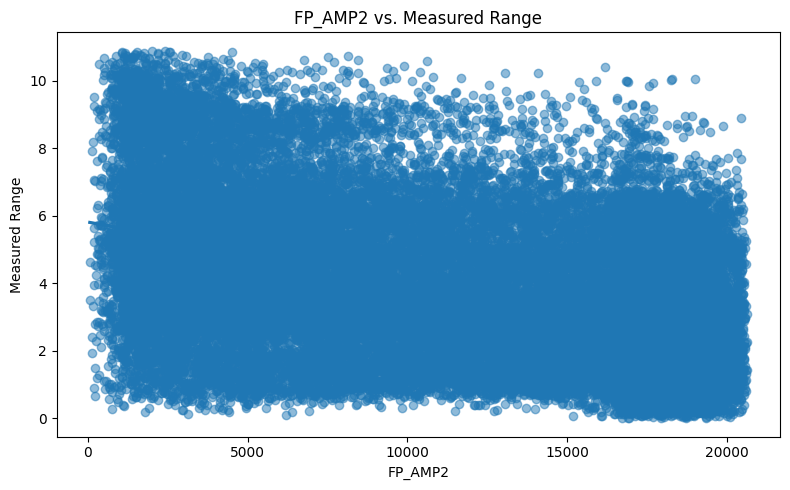

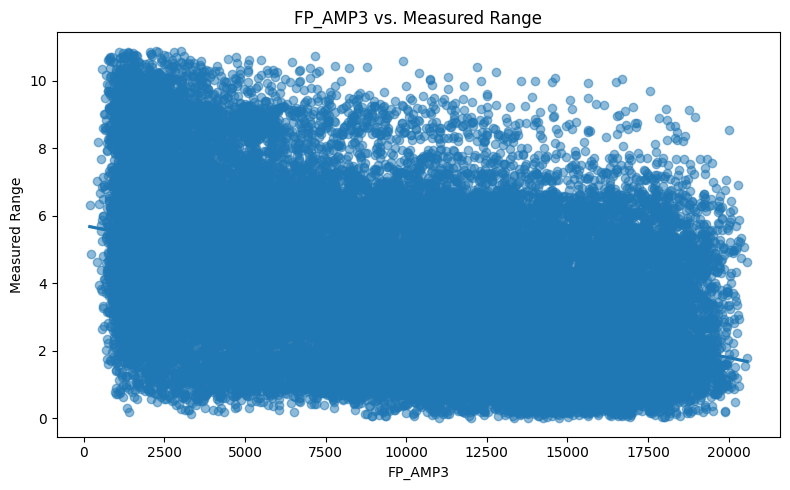

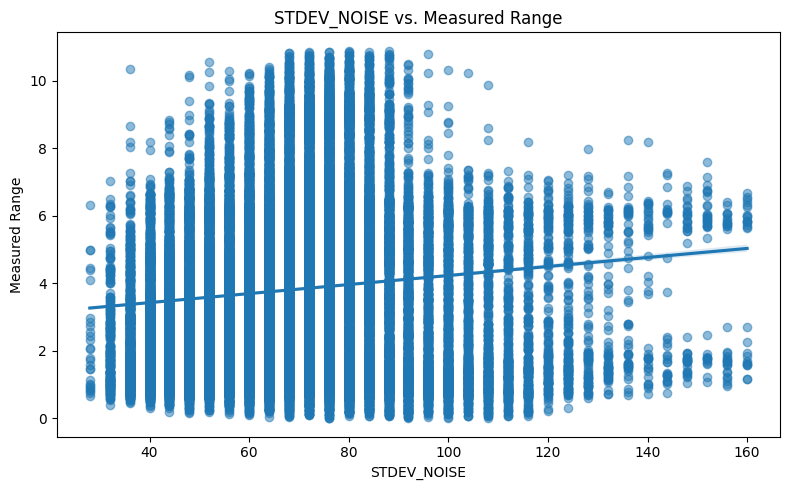

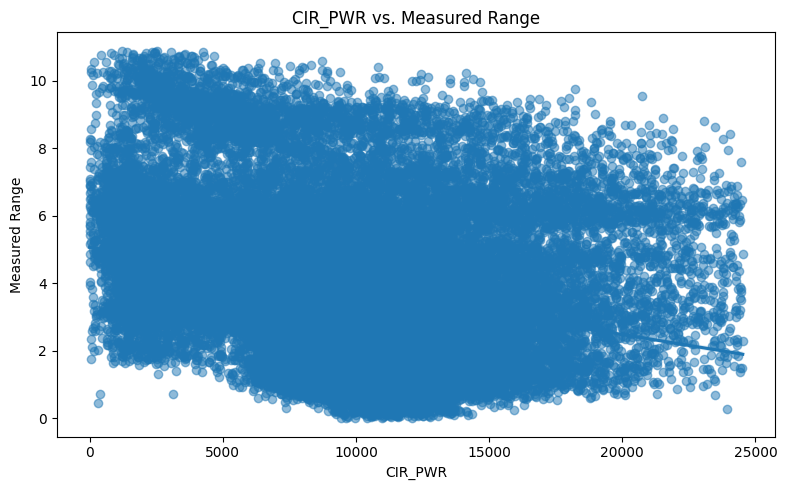

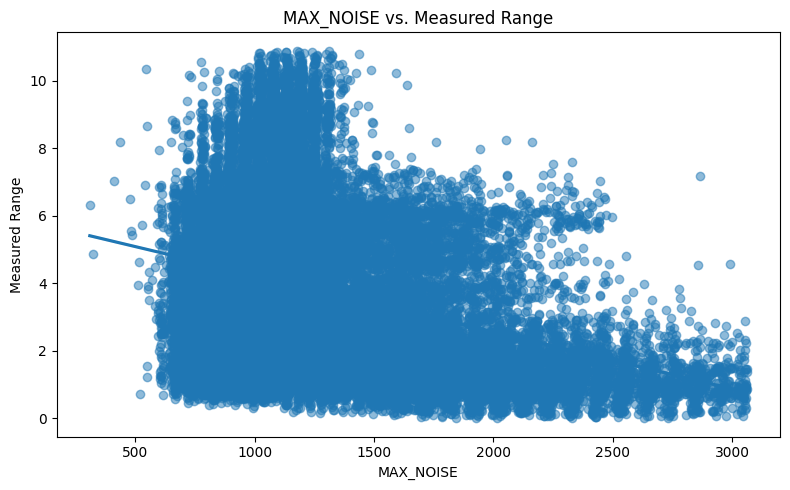

In [81]:
for feature in outlier_features:
    plt.figure(figsize=(7,5))
    sns.histplot(df_cleaned[feature], kde=True, bins=30)
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.tight_layout()
    plt.show()
    
regression_features = [f for f in outlier_features if f != 'measured_range']
for feature in regression_features:
    plt.figure(figsize=(8,5))
    sns.regplot(data=df_cleaned, x=feature, y='measured_range', scatter_kws={'alpha':0.5})
    plt.title(f"{feature} vs. Measured Range")
    plt.xlabel(feature)
    plt.ylabel("Measured Range")
    plt.tight_layout()
    plt.show()

## Fast Fournier Transfrom (FFT)

Formula:


$T_f = \mu \cdot N \cdot r$


Where:
- \( T_f \) is the frictional torque
- \( \mu \) is the coefficient of friction
- \( N \) is the normal force
- \( r \) is the radius at which the force is applied






In [82]:
df_cleaned.shape

(40473, 1032)

In [83]:
df_cleaned.head()

,NLOS,measured_range,RXPACC,FP_AMP1,FP_AMP2,FP_AMP3,STDEV_NOISE,CIR_PWR,MAX_NOISE,FP_IDX,...,CIR_1010,CIR_1011,CIR_1012,CIR_1013,CIR_1014,CIR_1015,CIR_mean,CIR_std,CIR_max,CIR_energy
0,0.0,3.90,745.0,18712.0,10250.0,11576.0,64.0,11855.0,967.0,611.0,...,198.0,87.0,296.0,505.0,307.0,0.0,406.493609,1277.261626,23077.0,1.825546e+09
1,0.0,0.66,749.0,11239.0,6313.0,4712.0,64.0,18968.0,1133.0,447.0,...,187.0,213.0,202.0,89.0,103.0,0.0,462.274336,1731.995119,18968.0,3.265134e+09
2,1.0,7.86,746.0,4355.0,5240.0,3478.0,60.0,14699.0,894.0,723.0,...,124.0,329.0,207.0,96.0,218.0,0.0,517.443461,1433.695551,16809.0,2.360670e+09
3,1.0,3.48,750.0,8502.0,8416.0,5890.0,76.0,8748.0,1127.0,1024.0,...,434.0,397.0,290.0,155.0,342.0,256.0,421.249754,1079.099721,15742.0,1.363556e+09
4,0.0,1.19,746.0,17845.0,18095.0,12058.0,68.0,11380.0,1744.0,276.0,...,87.0,178.0,314.0,247.0,292.0,256.0,374.189774,1247.746056,19583.0,1.724178e+09


In [24]:
# Make a copy of the cleaned dataframe
df_fft = df_cleaned.copy()

# Identify CIR columns (1016 columns)
cir_columns = [col for col in df_fft.columns if 'CIR_' in col and col not in ['CIR_PWR', 'CIR_mean', 'CIR_max', 'CIR_std', 'CIR_energy']]

# Ensure CIR columns exist
if not cir_columns:
    raise ValueError("No CIR columns found!")

# Compute FFT for each row, keeping only 1016 CIR values
fft_values = df_fft[cir_columns].apply(lambda row: np.abs(fft(row.to_numpy())), axis=1)

# Create FFT column names
fft_columns = [f'FFT_{i}' for i in range(len(cir_columns))]  # 1016 FFT columns

# Convert FFT values into DataFrame
fft_df = pd.DataFrame(fft_values.tolist(), columns=fft_columns, index=df_fft.index)

# Concatenate FFT features while keeping the original dataset (except CIR columns)
df_fft = pd.concat([df_fft.drop(columns=cir_columns), fft_df], axis=1)

print(f"Dataset shape after replacing CIR with FFT features: {df_fft.shape}")

Dataset shape after replacing CIR with FFT features: (40473, 1032)


In [25]:
df_fft.head()

,NLOS,measured_range,RXPACC,FP_AMP1,FP_AMP2,FP_AMP3,STDEV_NOISE,CIR_PWR,MAX_NOISE,FP_IDX,...,FFT_1006,FFT_1007,FFT_1008,FFT_1009,FFT_1010,FFT_1011,FFT_1012,FFT_1013,FFT_1014,FFT_1015
0,0.0,3.90,745.0,18712.0,10250.0,11576.0,64.0,11855.0,967.0,611.0,...,147363.580386,156993.029852,157508.713787,159284.355187,164661.802783,170808.640426,169869.361433,170881.074380,172218.295753,176143.139130
1,0.0,0.66,749.0,11239.0,6313.0,4712.0,64.0,18968.0,1133.0,447.0,...,199736.436094,205347.386528,213356.614836,217296.396829,222944.309688,232368.316737,234558.979076,242363.138758,247273.488409,248007.108944
2,1.0,7.86,746.0,4355.0,5240.0,3478.0,60.0,14699.0,894.0,723.0,...,160064.552114,169194.398622,175908.800760,188432.403230,198740.768169,226308.229453,238309.603004,262890.558709,277560.207867,282638.075317
3,1.0,3.48,750.0,8502.0,8416.0,5890.0,76.0,8748.0,1127.0,1024.0,...,127889.940510,131819.209398,137981.690665,137379.511692,138569.940418,145046.920891,148356.463666,144111.339108,152201.642761,143584.438466
4,0.0,1.19,746.0,17845.0,18095.0,12058.0,68.0,11380.0,1744.0,276.0,...,114351.866172,117578.777597,124726.508044,128587.200245,126080.397723,128417.188951,130807.229975,140699.927983,145627.201594,149284.240427


In [26]:
# Ensure CIR columns exist
fft_columns = [col for col in df_fft.columns if 'FFT_' in col]
if not fft_columns:
    fft_columns = [f'CIR_{i}' for i in range(1016)]  # Ensure correct column names
    df_fft[fft_columns] = df_cleaned[fft_columns]  # Restore if missing

# Compute FFT features safely
df_fft['FFT_energy'] = df_fft[fft_columns].apply(lambda row: np.sum(np.abs(fft(row.to_numpy()))**2), axis=1)
df_fft['FFT_max_freq'] = df_fft[fft_columns].apply(lambda row: np.argmax(np.abs(fft(row.to_numpy()))), axis=1)
df_fft['FFT_mean'] = df_fft[fft_columns].apply(lambda row: np.mean(np.abs(fft(row.to_numpy()))), axis=1)
df_fft['FFT_std'] = df_fft[fft_columns].apply(lambda row: np.std(np.abs(fft(row.to_numpy()))), axis=1)

print(f"Dataset shape after extracting FFT features: {df_fft.shape}")

Dataset shape after extracting FFT features: (40473, 1036)


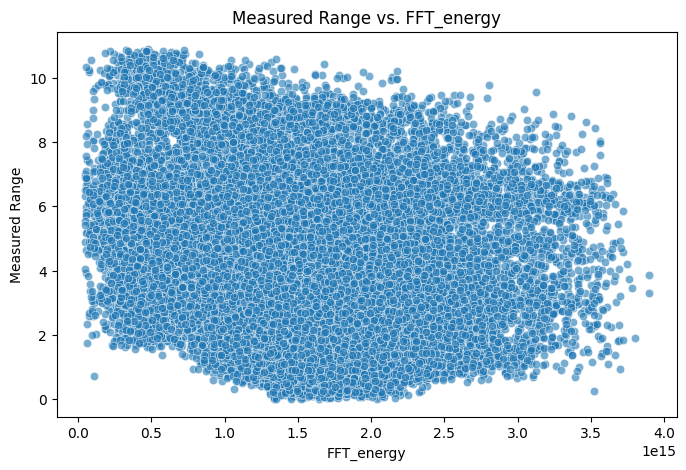

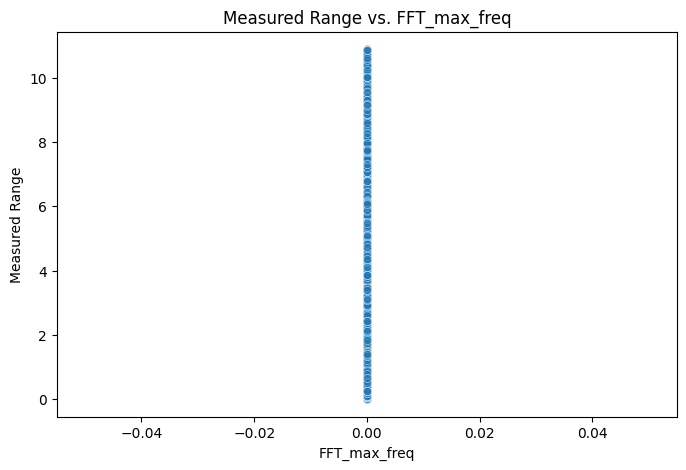

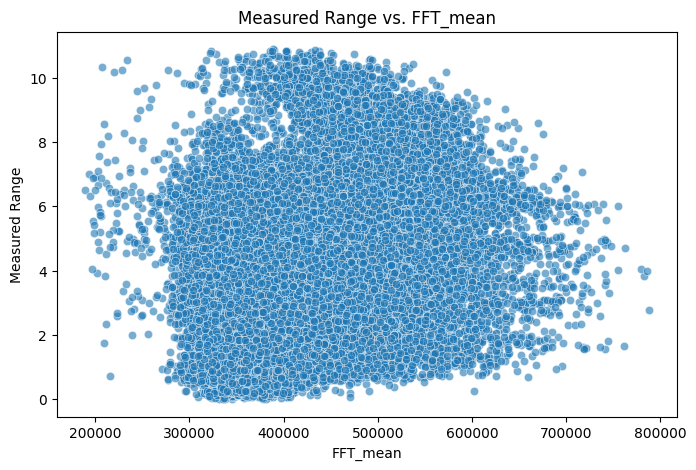

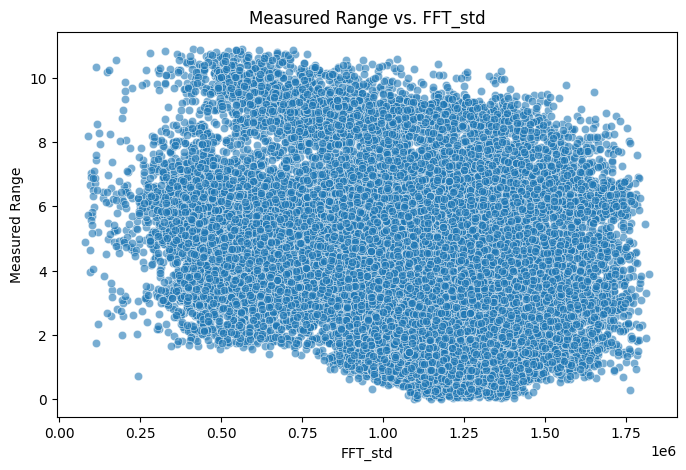

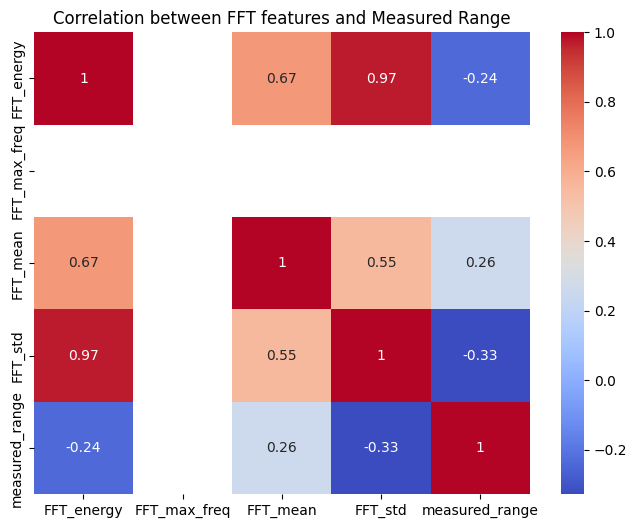

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Scatter plots for each FFT feature vs. Measured Range
fft_aggregated_features = ['FFT_energy', 'FFT_max_freq', 'FFT_mean', 'FFT_std']

for feature in fft_aggregated_features:
    plt.figure(figsize=(8,5))
    sns.scatterplot(x=df_fft[feature], y=df_fft['measured_range'], alpha=0.6)
    plt.title(f"Measured Range vs. {feature}")
    plt.xlabel(feature)
    plt.ylabel("Measured Range")
    plt.show()

# 2. Correlation heatmap between FFT features and Measured Range
corr_features = fft_aggregated_features + ['measured_range']
plt.figure(figsize=(8,6))
sns.heatmap(df_fft[corr_features].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation between FFT features and Measured Range")
plt.show()


# Data Mining

## Base Model

In [124]:
# -------------------------------
# Step 1: Split Data and Scale Features
# -------------------------------
X = df_fft.drop(columns=['measured_range'])
y = df_fft['measured_range']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames with original column names
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# Compute target range for normalization (if needed)
y_range = y.max() - y.min()

# -------------------------------
# Step 2: Define Base Regression Models
# -------------------------------
models = {
    'Decision Tree': DecisionTreeRegressor(max_depth=5, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'SVR': SVR(kernel='rbf'),
    'MLP (Neural Net)': MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42, early_stopping=True, validation_fraction=0.1),
    'LightGBM': lgb.LGBMRegressor(n_estimators=100, random_state=42)
}

# -------------------------------
# Step 3: Train & Evaluate Models
# -------------------------------
results = []
trained_models = {}
for name, model in models.items():
    model.fit(X_train_scaled_df, y_train)
    # Predictions on training and testing sets
    y_train_pred = model.predict(X_train_scaled_df)
    y_test_pred = model.predict(X_test_scaled_df)
    
    # Compute RMSE and R² for both training and testing sets
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    # Normalize RMSE by dividing by the range of y
    train_nrmse = train_rmse / y_range
    test_nrmse = test_rmse / y_range
    
    results.append({
        'Model': name,
        'Train_RMSE': train_rmse,
        'Test_RMSE': test_rmse,
        'Train_R2': train_r2,
        'Test_R2': test_r2,
        'Train_NRMSE': train_nrmse,
        'Test_NRMSE': test_nrmse
    })
    trained_models[name] = model

# -------------------------------
# Step 4: Results Table
# -------------------------------
results_df = pd.DataFrame(results).sort_values(by='Test_RMSE', ascending=True)
print(results_df)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.127182 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 262490
[LightGBM] [Info] Number of data points in the train set: 32378, number of used features: 1034
[LightGBM] [Info] Start training from score 3.814284
              Model  Train_RMSE  Test_RMSE  Train_R2   Test_R2  Train_NRMSE  \
1     Random Forest    0.449544   1.195790  0.962391  0.731293     0.041280   
4          LightGBM    1.059561   1.215307  0.791071  0.722450     0.097297   
3  MLP (Neural Net)    0.973276   1.339844  0.823714  0.662653     0.089373   
2               SVR    1.262313   1.453774  0.703462  0.602843     0.115915   
0     Decision Tree    1.489787   1.512267  0.586957  0.570240     0.136803   

   Test_NRMSE  
1    0.109806  
4    0.111598  
3    0.123034  
2    0.133496  
0    0.138868  


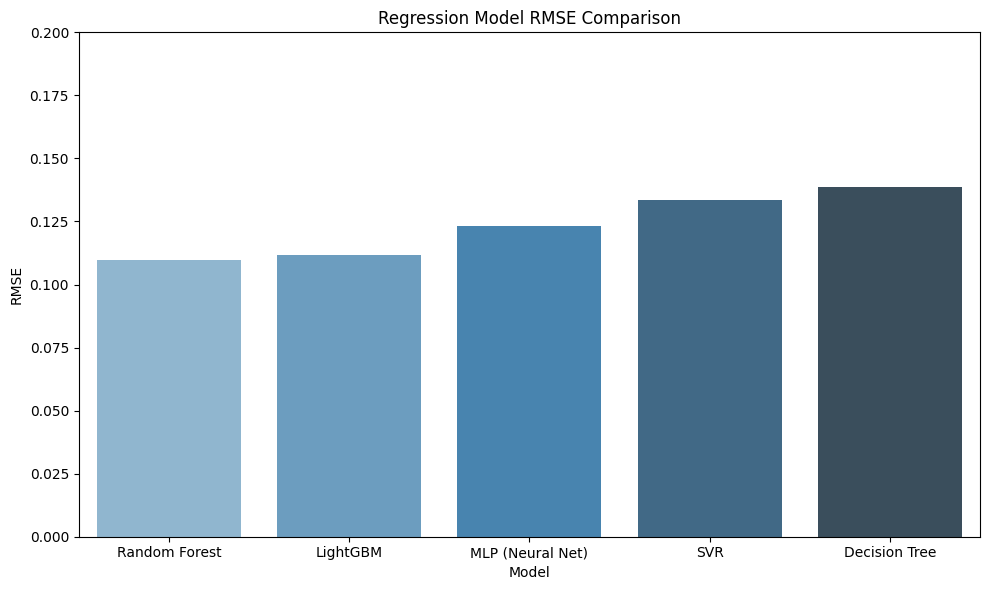

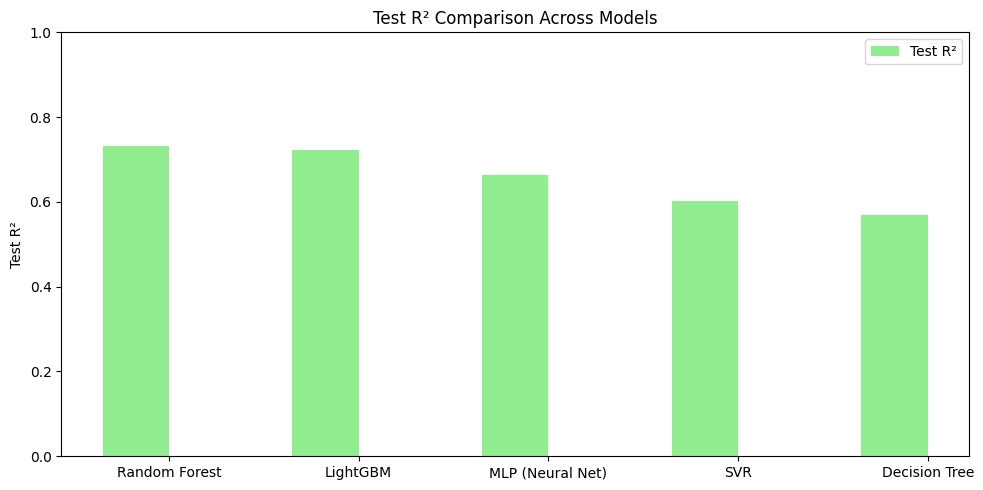

In [136]:
import matplotlib.gridspec as gridspec
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Create a new DataFrame for plotting all models
all_models_df = results_df.copy()

x = np.arange(len(results_df))
width = 0.35  # width of the bars

plt.figure(figsize=(10,6))
sns.barplot(x='Model', y='Test_NRMSE', data=all_models_df, hue='Model', palette='Blues_d', dodge=False, legend=False)
plt.title('Regression Model RMSE Comparison')
plt.ylabel('RMSE')
plt.ylim(0, 0.2)  # Set the upper limit to 5, as desired
plt.tight_layout()
plt.show()

# Plot Test_R²
plt.figure(figsize=(10, 5))
plt.bar(x - width/2, results_df['Test_R2'], width, label='Test R²', color='lightgreen')
plt.xticks(x, results_df['Model'])
plt.ylabel('Test R²')
plt.title('Test R² Comparison Across Models')
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()


## Feature Importance

### <font color='red'>Random Forest</font>

Random Forest Regressor selected 977 features (99% threshold)


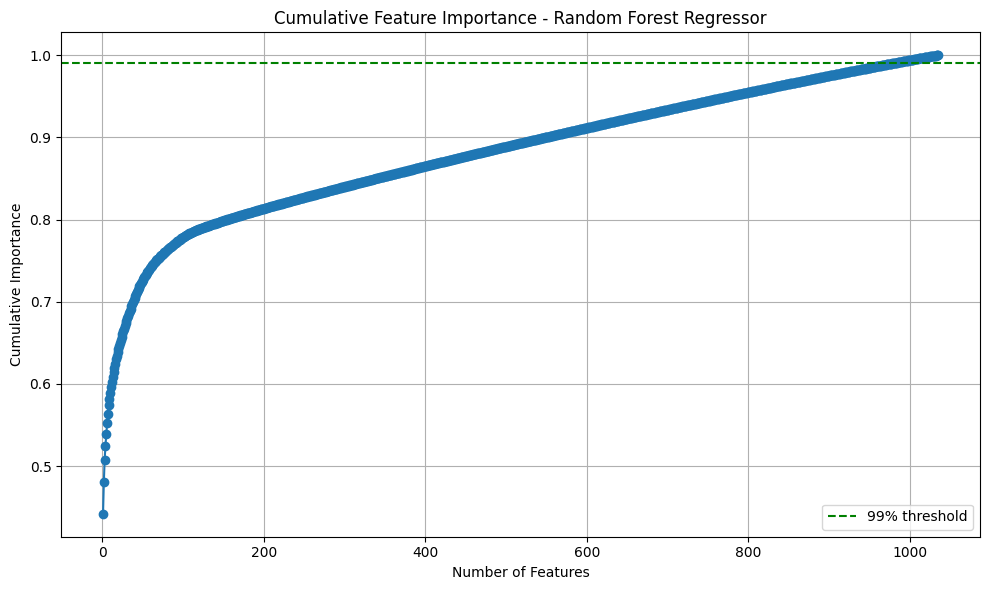

In [145]:
# Retrieve the trained Random Forest model
rf_model = trained_models['Random Forest']

# Extract feature importances
rf_importances = rf_model.feature_importances_
rf_features = pd.Series(rf_importances, index=X.columns).sort_values(ascending=False)
cumulative_rf = rf_features.cumsum()

# Select top features covering 95% of the cumulative importance
rf_selected_features = rf_features[cumulative_rf <= 0.99].index
print(f"Random Forest Regressor selected {len(rf_selected_features)} features (99% threshold)")

# Plot cumulative feature importance
plt.figure(figsize=(10, 6))
plt.plot(np.arange(1, len(cumulative_rf) + 1), cumulative_rf.values, marker='o')
plt.axhline(y=0.99, color='g', linestyle='--', label='99% threshold')
plt.xlabel('Number of Features')
plt.ylabel('Cumulative Importance')
plt.title('Cumulative Feature Importance - Random Forest Regressor')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [144]:
# Step 1: Extract selected features from Random Forest
rflist_selected_features = list(rf_selected_features)

# Step 2: Separate FFT and non-FFT columns
rf_fft_selected = [col for col in rflist_selected_features if 'FFT_' in col]
rf_non_fft_selected = [col for col in rflist_selected_features if 'FFT_' not in col]

print(f"=== Random Forest Feature Selection ===")
print(f"Total selected features: {len(rflist_selected_features)}")
print(f"FFT selected features: {len(rf_fft_selected)}")
print(f"Non-FFT selected features: {len(rf_non_fft_selected)}")

# Optional: View which columns are which
print("FFT columns:\n", rf_fft_selected[:])
print("Non-FFT columns:\n", rf_non_fft_selected[:10])


=== Random Forest Feature Selection ===
Total selected features: 977
FFT selected features: 962
Non-FFT selected features: 15
FFT columns:
 ['FFT_0', 'FFT_2', 'FFT_1014', 'FFT_1015', 'FFT_1', 'FFT_1013', 'FFT_10', 'FFT_11', 'FFT_3', 'FFT_1005', 'FFT_1006', 'FFT_21', 'FFT_28', 'FFT_995', 'FFT_mean', 'FFT_1007', 'FFT_9', 'FFT_992', 'FFT_988', 'FFT_25', 'FFT_24', 'FFT_13', 'FFT_12', 'FFT_1004', 'FFT_1012', 'FFT_1003', 'FFT_994', 'FFT_4', 'FFT_1008', 'FFT_991', 'FFT_972', 'FFT_8', 'FFT_985', 'FFT_23', 'FFT_987', 'FFT_993', 'FFT_29', 'FFT_std', 'FFT_27', 'FFT_5', 'FFT_989', 'FFT_990', 'FFT_986', 'FFT_1011', 'FFT_30', 'FFT_983', 'FFT_energy', 'FFT_26', 'FFT_7', 'FFT_979', 'FFT_973', 'FFT_1009', 'FFT_40', 'FFT_22', 'FFT_43', 'FFT_32', 'FFT_996', 'FFT_975', 'FFT_997', 'FFT_37', 'FFT_19', 'FFT_998', 'FFT_999', 'FFT_508', 'FFT_1002', 'FFT_14', 'FFT_6', 'FFT_39', 'FFT_15', 'FFT_16', 'FFT_1000', 'FFT_33', 'FFT_1001', 'FFT_18', 'FFT_971', 'FFT_17', 'FFT_20', 'FFT_976', 'FFT_41', 'FFT_984', 'FFT_44'

### <font color='red'>LightGBM</font>

LightGBM Regressor selected 454 features (99% threshold)


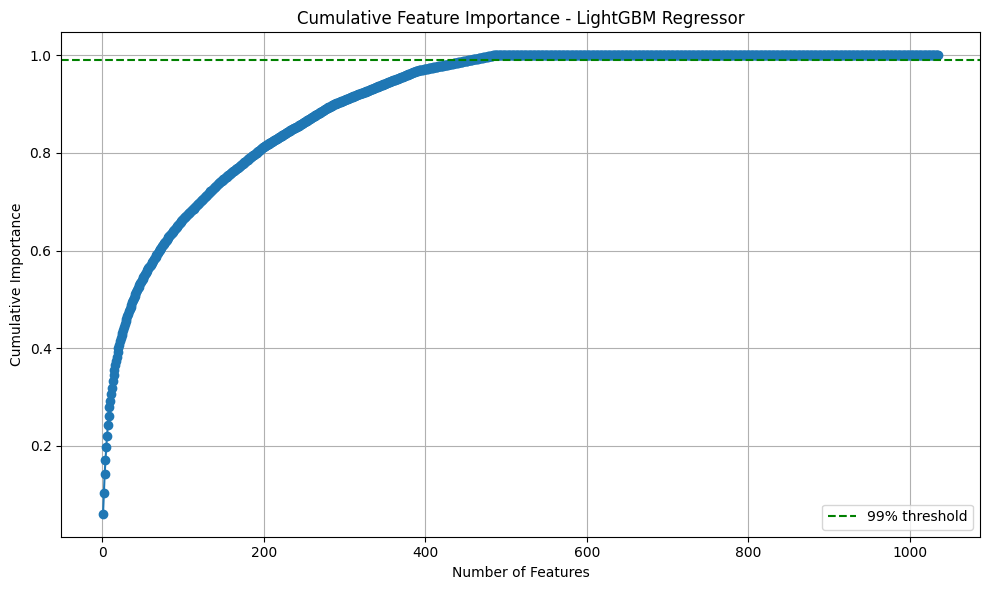

In [149]:
# Retrieve the trained LightGBM model 
lgb_model = trained_models['LightGBM']

# Extract LightGBM feature importances
lgb_importances = lgb_model.feature_importances_
lgb_importances = lgb_importances / lgb_importances.sum()
lgb_features = pd.Series(lgb_importances, index=X.columns).sort_values(ascending=False)
cumulative_lgb = lgb_features.cumsum()

# Select top features covering 95% of the cumulative importance
lgb_selected_features = lgb_features[cumulative_lgb <= 0.99].index
print(f"LightGBM Regressor selected {len(lgb_selected_features)} features (99% threshold)")

# Plot cumulative feature importance for LightGBM
plt.figure(figsize=(10, 6))
plt.plot(np.arange(1, len(cumulative_lgb) + 1), cumulative_lgb.values, marker='o')
plt.axhline(y=0.99, color='g', linestyle='--', label='99% threshold')
plt.xlabel('Number of Features')
plt.ylabel('Cumulative Importance')
plt.title('Cumulative Feature Importance - LightGBM Regressor')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [150]:
# Step 1: Extract selected features from LightGBM
lgblist_selected_features = list(lgb_selected_features)

# Step 2: Separate FFT and non-FFT columns
lgb_fft_selected = [col for col in lgblist_selected_features if 'FFT_' in col]
lgb_non_fft_selected = [col for col in lgblist_selected_features if 'FFT_' not in col]

print(f"=== LightGBM Feature Selection ===")
print(f"Total selected features: {len(lgblist_selected_features)}")
print(f"FFT selected features: {len(lgb_fft_selected)}")
print(f"Non-FFT selected features: {len(lgb_non_fft_selected)}")

# Optional: View which columns are which
print("FFT columns:\n", lgb_fft_selected[:])
print("Non-FFT columns:\n", lgb_non_fft_selected[:10])


=== LightGBM Feature Selection ===
Total selected features: 454
FFT selected features: 440
Non-FFT selected features: 14
FFT columns:
 ['FFT_2', 'FFT_3', 'FFT_1', 'FFT_9', 'FFT_0', 'FFT_8', 'FFT_10', 'FFT_4', 'FFT_11', 'FFT_17', 'FFT_12', 'FFT_18', 'FFT_16', 'FFT_21', 'FFT_23', 'FFT_24', 'FFT_mean', 'FFT_25', 'FFT_13', 'FFT_48', 'FFT_31', 'FFT_43', 'FFT_5', 'FFT_15', 'FFT_38', 'FFT_28', 'FFT_29', 'FFT_20', 'FFT_47', 'FFT_22', 'FFT_14', 'FFT_473', 'FFT_30', 'FFT_33', 'FFT_27', 'FFT_62', 'FFT_35', 'FFT_45', 'FFT_39', 'FFT_71', 'FFT_82', 'FFT_42', 'FFT_7', 'FFT_59', 'FFT_50', 'FFT_41', 'FFT_506', 'FFT_95', 'FFT_94', 'FFT_80', 'FFT_32', 'FFT_40', 'FFT_26', 'FFT_494', 'FFT_34', 'FFT_60', 'FFT_44', 'FFT_67', 'FFT_84', 'FFT_75', 'FFT_49', 'FFT_224', 'FFT_19', 'FFT_37', 'FFT_129', 'FFT_207', 'FFT_6', 'FFT_111', 'FFT_std', 'FFT_36', 'FFT_66', 'FFT_485', 'FFT_46', 'FFT_507', 'FFT_343', 'FFT_315', 'FFT_210', 'FFT_198', 'FFT_339', 'FFT_61', 'FFT_461', 'FFT_72', 'FFT_470', 'FFT_404', 'FFT_382', 'FF

### <font color='red'>MLP</font>

MLP Regressor selected 178 features (95% threshold)


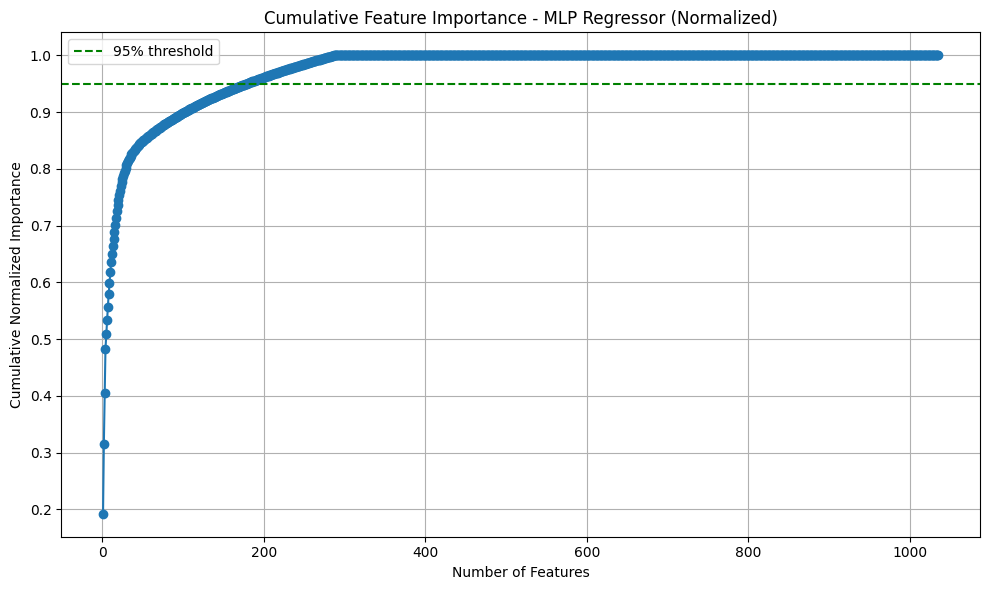

In [182]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Retrieve the trained MLPRegressor model
mlp_model = trained_models['MLP (Neural Net)']

# Use permutation importance on the test set (ensure X_test_scaled_df is a DataFrame with proper column names)
result = permutation_importance(mlp_model, X_test_scaled_df, y_test, n_repeats=10, random_state=42)

# Get the mean importances and normalize them so that they sum to 1
mlp_importances = result.importances_mean
mlp_features = pd.Series(mlp_importances, index=X_test_scaled_df.columns)
mlp_features_norm = mlp_features / mlp_features.sum()  # Normalize importances to sum to 1
mlp_features_norm = mlp_features_norm.sort_values(ascending=False)

# Compute cumulative normalized importance
cumulative_mlp = mlp_features_norm.cumsum()
cumulative_mlp = np.minimum(cumulative_mlp, 1.0)

# Select top features covering 95% of the normalized cumulative importance
mlp_selected_features = mlp_features_norm[cumulative_mlp <= 0.95].index
print(f"MLP Regressor selected {len(mlp_selected_features)} features (95% threshold)")

# Plot cumulative normalized feature importance for MLP using permutation importance
plt.figure(figsize=(10, 6))
plt.plot(np.arange(1, len(cumulative_mlp) + 1), cumulative_mlp.values, marker='o')
plt.axhline(y=0.95, color='g', linestyle='--', label='95% threshold')
plt.xlabel('Number of Features')
plt.ylabel('Cumulative Normalized Importance')
plt.title('Cumulative Feature Importance - MLP Regressor (Normalized)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [166]:
# Step 1: Extract selected features from MLP
mlplist_selected_features = list(mlp_selected_features)

# Step 2: Separate FFT and non-FFT columns
mlp_fft_selected = [col for col in mlplist_selected_features if 'FFT_' in col]
mlp_non_fft_selected = [col for col in mlplist_selected_features if 'FFT_' not in col]

print(f"=== MLP Feature Selection ===")
print(f"Total selected features: {len(mlplist_selected_features)}")
print(f"FFT selected features: {len(mlp_fft_selected)}")
print(f"Non-FFT selected features: {len(mlp_non_fft_selected)}")

# Optional: View which columns are which
print("FFT columns:\n", mlp_fft_selected[:])
print("Non-FFT columns:\n", mlp_non_fft_selected[:10])

=== MLP Feature Selection ===
Total selected features: 178
FFT selected features: 164
Non-FFT selected features: 14
FFT columns:
 ['FFT_energy', 'FFT_3', 'FFT_1013', 'FFT_1014', 'FFT_2', 'FFT_1012', 'FFT_1', 'FFT_1015', 'FFT_8', 'FFT_4', 'FFT_9', 'FFT_1007', 'FFT_1008', 'FFT_10', 'FFT_1006', 'FFT_std', 'FFT_1005', 'FFT_11', 'FFT_1011', 'FFT_5', 'FFT_1009', 'FFT_7', 'FFT_1010', 'FFT_742', 'FFT_1004', 'FFT_6', 'FFT_mean', 'FFT_993', 'FFT_979', 'FFT_978', 'FFT_56', 'FFT_37', 'FFT_12', 'FFT_17', 'FFT_0', 'FFT_46', 'FFT_744', 'FFT_285', 'FFT_999', 'FFT_919', 'FFT_992', 'FFT_23', 'FFT_251', 'FFT_103', 'FFT_297', 'FFT_980', 'FFT_372', 'FFT_998', 'FFT_78', 'FFT_272', 'FFT_566', 'FFT_957', 'FFT_35', 'FFT_974', 'FFT_849', 'FFT_287', 'FFT_977', 'FFT_981', 'FFT_995', 'FFT_877', 'FFT_39', 'FFT_24', 'FFT_59', 'FFT_77', 'FFT_21', 'FFT_747', 'FFT_274', 'FFT_938', 'FFT_18', 'FFT_452', 'FFT_44', 'FFT_426', 'FFT_988', 'FFT_90', 'FFT_809', 'FFT_213', 'FFT_960', 'FFT_729', 'FFT_41', 'FFT_889', 'FFT_155', '

## Principle Component Analysis (PCA)

### <font color='red'>Random Forest</font>

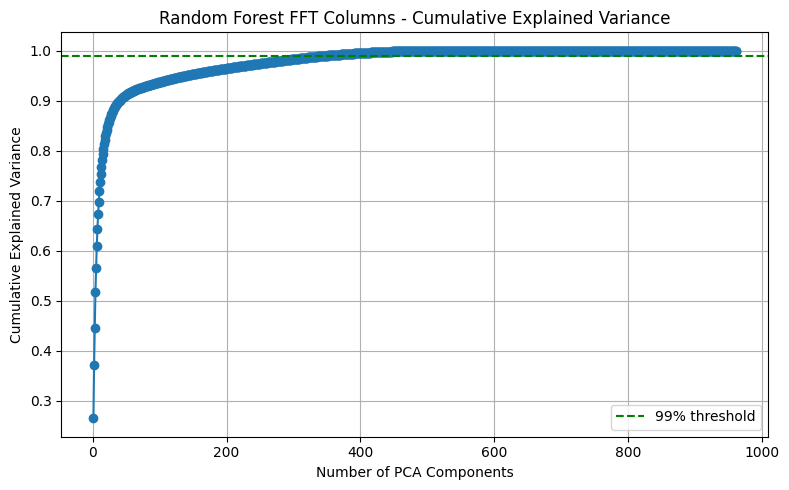

Random Forest Regression PCA - reduce to 349 components (99% explained variance)


In [180]:
# Scale the selected features
scaler_rf = StandardScaler()
X_rf_fft_scaled = scaler_rf.fit_transform(df_fft[rf_fft_selected])

# Fit PCA on the scaled selected features
pca_rf = PCA()
pca_rf.fit(X_rf_fft_scaled)

# Compute cumulative explained variance
explained_var_rf = np.cumsum(pca_rf.explained_variance_ratio_)
n_components_rf = np.argmax(explained_var_rf >= 0.99) + 1

# Plot cumulative explained variance
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(explained_var_rf) + 1), explained_var_rf, marker='o')
plt.axhline(0.99, color='g', linestyle='--', label='99% threshold')
plt.title('Random Forest FFT Columns - Cumulative Explained Variance')
plt.xlabel('Number of PCA Components')
plt.ylabel('Cumulative Explained Variance')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Random Forest Regression PCA - reduce to {n_components_rf} components (99% explained variance)")


In [181]:
pca_rf_final = PCA(n_components=n_components_rf)
X_rf_final = pca_rf_final.fit_transform(X_rf_fft_scaled)

# Combine the reduced FFT PCA components with the non-FFT features BEFORE splitting
X_rf_combined = np.concatenate([X_rf_final, df_fft[rf_non_fft_selected].values], axis=1)

# Split the combined data into training and testing sets
X_rf_train, X_rf_test, y_rf_train, y_rf_test = train_test_split(
    X_rf_combined, y, test_size=0.2, random_state=42
)

# Train a regression model (RandomForestRegressor in this example)
clf_rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
clf_rf_reg.fit(X_rf_train, y_rf_train)
y_rf_pred = clf_rf_reg.predict(X_rf_test)

# Evaluate performance on training data
y_rf_train_pred = clf_rf_reg.predict(X_rf_train)
train_rmse = np.sqrt(mean_squared_error(y_rf_train, y_rf_train_pred))
train_r2 = r2_score(y_rf_train, y_rf_train_pred)

# Evaluate performance on testing data
test_rmse = np.sqrt(mean_squared_error(y_rf_test, y_rf_pred))
test_r2 = r2_score(y_rf_test, y_rf_pred)

# Compute normalized RMSE (NRMSE) using the range of the target variable
y_range = y.max() - y.min()
train_nrmse = train_rmse / y_range
test_nrmse = test_rmse / y_range

# Create a results DataFrame for clear output
results = pd.DataFrame({
    'Train_RMSE': [train_rmse],
    'Test_RMSE': [test_rmse],
    'Train_R²': [train_r2],
    'Test_R²': [test_r2],
    'Train_NRMSE': [train_nrmse],
    'Test_NRMSE': [test_nrmse]
})

print("Random Forest Regressor on PCA + non-FFT Data:")
print(results)

Random Forest Regressor on PCA + non-FFT Data:
   Train_RMSE  Test_RMSE  Train_R²   Test_R²  Train_NRMSE  Test_NRMSE
0      0.4816   1.287254  0.956836  0.688615     0.044224    0.118205


<div align="left">
Base Model Results:
    
| Train_RMSE | Test_RMSE | Train_R²  | Test_R²  | Train_NRMSE | Test_NRMSE |
|:-----------|:----------|:----------|:---------|:------------|:-----------|
| 0.449544   | 1.195790  | 0.962391  | 0.731293 | 0.041280    | 0.109806   |

</div>


### <font color='red'>LightGBM</font>

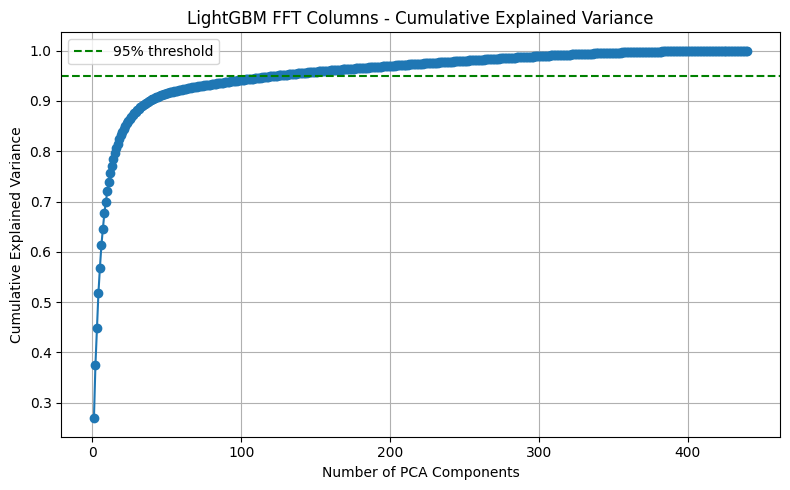

LightGBM Regression PCA - reduce to 123 components (95% explained variance)


In [151]:
# Scale the selected features
scaler_lgb = StandardScaler()
X_lgb_fft_scaled = scaler_lgb.fit_transform(df_fft[lgb_fft_selected])

# Fit PCA on the scaled selected features
pca_lgb = PCA()
pca_lgb.fit(X_lgb_fft_scaled)

# Compute cumulative explained variance
explained_var_lgb = np.cumsum(pca_lgb.explained_variance_ratio_)
n_components_lgb = np.argmax(explained_var_lgb >= 0.95) + 1

# Plot cumulative explained variance
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(explained_var_lgb) + 1), explained_var_lgb, marker='o')
plt.axhline(0.95, color='g', linestyle='--', label='95% threshold')
plt.title('LightGBM FFT Columns - Cumulative Explained Variance')
plt.xlabel('Number of PCA Components')
plt.ylabel('Cumulative Explained Variance')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"LightGBM Regression PCA - reduce to {n_components_lgb} components (95% explained variance)")


In [152]:
pca_lgb_final = PCA(n_components=n_components_lgb)
X_lgb_final = pca_lgb_final.fit_transform(X_lgb_fft_scaled)

# Create feature names for PCA components
pca_feature_names = [f'PCA_{i+1}' for i in range(X_lgb_final.shape[1])]
non_fft_feature_names = list(df_fft[lgb_non_fft_selected].columns)
combined_feature_names = pca_feature_names + non_fft_feature_names

# Combine the PCA-transformed FFT features with the non-FFT features
# (Assuming X_lgb_combined was created as follows)
X_lgb_combined = np.concatenate([X_lgb_final, df_fft[lgb_non_fft_selected].values], axis=1)

# Convert the combined array to a DataFrame with proper column names
X_lgb_combined_df = pd.DataFrame(X_lgb_combined, columns=combined_feature_names)

# Split the combined data into training and testing sets
X_lgb_train, X_lgb_test, y_lgb_train, y_lgb_test = train_test_split(
    X_lgb_combined_df, y, test_size=0.2, random_state=42
)

# Train a LightGBM Regressor
clf_lgb_reg = lgb.LGBMRegressor(n_estimators=100, random_state=42)
clf_lgb_reg.fit(X_lgb_train, y_lgb_train)

# Predictions on training and testing sets
y_lgb_train_pred = clf_lgb_reg.predict(X_lgb_train)
y_lgb_test_pred = clf_lgb_reg.predict(X_lgb_test)

# Evaluate performance on training data
train_rmse = np.sqrt(mean_squared_error(y_lgb_train, y_lgb_train_pred))
train_r2 = r2_score(y_lgb_train, y_lgb_train_pred)

# Evaluate performance on testing data
test_rmse = np.sqrt(mean_squared_error(y_lgb_test, y_lgb_test_pred))
test_r2 = r2_score(y_lgb_test, y_lgb_test_pred)

# Normalize RMSE using the range of y
y_range = y.max() - y.min()
train_nrmse = train_rmse / y_range
test_nrmse = test_rmse / y_range

# Create a results DataFrame for display
results_lgb = pd.DataFrame({
    'Train_RMSE': [train_rmse],
    'Test_RMSE': [test_rmse],
    'Train_R²': [train_r2],
    'Test_R²': [test_r2],
    'Train_NRMSE': [train_nrmse],
    'Test_NRMSE': [test_nrmse]
})

print("LightGBM on PCA + non-FFT Data:")
print(results_lgb)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011444 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 34006
[LightGBM] [Info] Number of data points in the train set: 32378, number of used features: 137
[LightGBM] [Info] Start training from score 3.814284
LightGBM on PCA + non-FFT Data:
   Train_RMSE  Test_RMSE  Train_R²   Test_R²  Train_NRMSE  Test_NRMSE
0    1.115535   1.286173  0.768414  0.689138     0.102437    0.118106


Base Model Results:

<div align="left">

| Train_RMSE | Test_RMSE | Train_R²  | Test_R²  | Train_NRMSE | Test_NRMSE |
|:-----------|:----------|:----------|:---------|:------------|:-----------|
| 1.059561   | 1.215307  | 0.791071  | 0.722450 | 0.097297    | 0.111598   |

</div>


### <font color='red'>MLP</font>

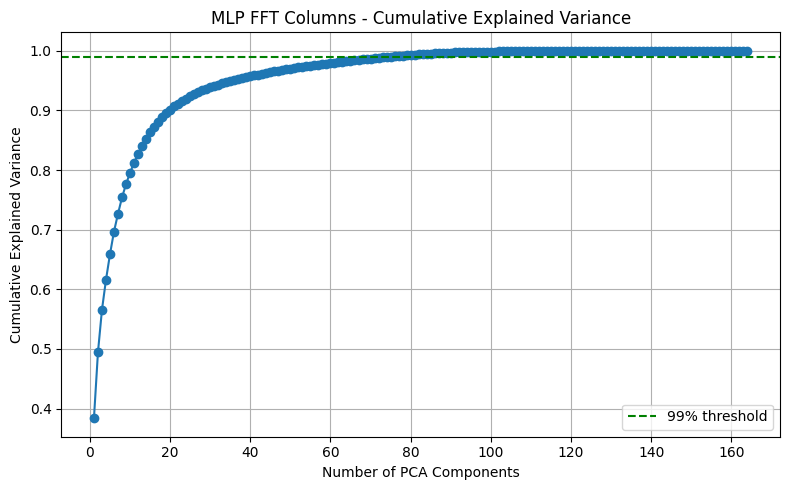

MLP Regression PCA - reduce to 105 components (95% explained variance)


In [176]:
# Scale the selected features for MLP
scaler_mlp = StandardScaler()
X_mlp_fft_scaled = scaler_mlp.fit_transform(df_fft[mlp_fft_selected])

# Fit PCA on the scaled selected features for MLP
pca_mlp = PCA()
pca_mlp.fit(X_mlp_fft_scaled)

# Compute cumulative explained variance
explained_var_mlp = np.cumsum(pca_mlp.explained_variance_ratio_)
n_components_mlp = np.argmax(explained_var_mlp >= 0.999) + 1

# Plot cumulative explained variance for MLP
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(explained_var_mlp) + 1), explained_var_mlp, marker='o')
plt.axhline(0.99, color='g', linestyle='--', label='99% threshold')
plt.title('MLP FFT Columns - Cumulative Explained Variance')
plt.xlabel('Number of PCA Components')
plt.ylabel('Cumulative Explained Variance')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"MLP Regression PCA - reduce to {n_components_mlp} components (95% explained variance)")

In [179]:
pca_mlp_final = PCA(n_components=n_components_mlp)
X_mlp_final = pca_mlp_final.fit_transform(X_mlp_fft_scaled)

# Scale the non-FFT features for MLP
scaler_non_fft = StandardScaler()
X_mlp_non_fft_scaled = scaler_non_fft.fit_transform(df_fft[mlp_non_fft_selected])

# Create feature names for the PCA components
pca_feature_names = [f'PCA_{i+1}' for i in range(X_mlp_final.shape[1])]
non_fft_feature_names = list(df_fft[mlp_non_fft_selected].columns)
combined_feature_names = pca_feature_names + non_fft_feature_names

# Combine the PCA-transformed FFT features with the scaled non-FFT features BEFORE splitting
X_mlp_combined = np.concatenate([X_mlp_final, X_mlp_non_fft_scaled], axis=1)

# Convert the combined array to a DataFrame with proper column names
X_mlp_combined_df = pd.DataFrame(X_mlp_combined, columns=combined_feature_names)

# Split the combined data into training and testing sets
X_mlp_train, X_mlp_test, y_mlp_train, y_mlp_test = train_test_split(
    X_mlp_combined_df, y, test_size=0.2, random_state=42
)

# Train an MLPRegressor with early stopping
clf_mlp_reg = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)
clf_mlp_reg.fit(X_mlp_train, y_mlp_train)

# Make predictions on training and testing sets
y_mlp_train_pred = clf_mlp_reg.predict(X_mlp_train)
y_mlp_test_pred = clf_mlp_reg.predict(X_mlp_test)

# Compute RMSE and R² for both training and testing sets
train_rmse = np.sqrt(mean_squared_error(y_mlp_train, y_mlp_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_mlp_test, y_mlp_test_pred))
train_r2 = r2_score(y_mlp_train, y_mlp_train_pred)
test_r2 = r2_score(y_mlp_test, y_mlp_test_pred)

# Compute normalized RMSE (NRMSE) using the range of the target variable
y_range = y.max() - y.min()
train_nrmse = train_rmse / y_range
test_nrmse = test_rmse / y_range

# Create a results DataFrame for display
results_mlp = pd.DataFrame({
    'Train_RMSE': [train_rmse],
    'Test_RMSE': [test_rmse],
    'Train_R²': [train_r2],
    'Test_R²': [test_r2],
    'Train_NRMSE': [train_nrmse],
    'Test_NRMSE': [test_nrmse]
})

print("MLP Regressor on PCA + non-FFT Data:")
print(results_mlp)

MLP Regressor on PCA + non-FFT Data:
   Train_RMSE  Test_RMSE  Train_R²  Test_R²  Train_NRMSE  Test_NRMSE
0    1.023679   1.209669  0.804982  0.72502     0.094002    0.111081


Base Model Results:

<div align="left">

| Train_RMSE | Test_RMSE | Train_R²  | Test_R²  | Train_NRMSE | Test_NRMSE |
|:-----------|:----------|:----------|:---------|:------------|:-----------|
| 0.973276   | 1.339844  | 0.823714  | 0.662653 | 0.089373    | 0.123034   |

</div>


## Model Tuning

### <font color='red'>Random Forest</font>

In [183]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Define a parameter grid for RandomForestRegressor
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize GridSearchCV with RandomForestRegressor using negative MSE as scoring
grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

# Fit grid search on the training data
grid_rf.fit(X_rf_train, y_rf_train)

# Print the best parameters
print("Best RandomForest parameters:", grid_rf.best_params_)

# Get the best estimator and evaluate it on both training and test sets
best_rf = grid_rf.best_estimator_

# Predictions for training and testing data
y_rf_train_pred = best_rf.predict(X_rf_train)
y_rf_test_pred = best_rf.predict(X_rf_test)

# Compute RMSE and R² for training data
train_rmse = np.sqrt(mean_squared_error(y_rf_train, y_rf_train_pred))
train_r2 = r2_score(y_rf_train, y_rf_train_pred)

# Compute RMSE and R² for test data
test_rmse = np.sqrt(mean_squared_error(y_rf_test, y_rf_test_pred))
test_r2 = r2_score(y_rf_test, y_rf_test_pred)

# Compute normalized RMSE (NRMSE) using the range of the target variable
y_range = y.max() - y.min()
train_nrmse = train_rmse / y_range
test_nrmse = test_rmse / y_range

# Create a results DataFrame for display
results_rf = pd.DataFrame({
    'Train_RMSE': [train_rmse],
    'Test_RMSE': [test_rmse],
    'Train_R²': [train_r2],
    'Test_R²': [test_r2],
    'Train_NRMSE': [train_nrmse],
    'Test_NRMSE': [test_nrmse]
})

print("Best RandomForest Regressor Performance Metrics:")
print(results_rf)


Best RandomForest parameters: {'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}
Best RandomForest Regressor Performance Metrics:
   Train_RMSE  Test_RMSE  Train_R²   Test_R²  Train_NRMSE  Test_NRMSE
0    0.617709   1.283841  0.928991  0.690264     0.056723    0.117892


### <font color='red'>LightGBM</font>

In [185]:
import lightgbm as lgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Define a parameter grid for LightGBMRegressor
param_grid_lgb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [None, 5, 10]
}

# Initialize GridSearchCV with LightGBMRegressor using negative MSE as scoring
grid_lgb = GridSearchCV(
    lgb.LGBMRegressor(random_state=42),
    param_grid_lgb,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

# Fit grid search on the training data
grid_lgb.fit(X_lgb_train, y_lgb_train)

# Print the best parameters
print("Best LightGBM parameters:", grid_lgb.best_params_)

# Get the best estimator and evaluate it on both training and test sets
best_lgb = grid_lgb.best_estimator_

# Predictions for training and testing data
y_lgb_train_pred = best_lgb.predict(X_lgb_train)
y_lgb_test_pred = best_lgb.predict(X_lgb_test)

# Compute RMSE and R² for training data
train_rmse = np.sqrt(mean_squared_error(y_lgb_train, y_lgb_train_pred))
train_r2 = r2_score(y_lgb_train, y_lgb_train_pred)

# Compute RMSE and R² for test data
test_rmse = np.sqrt(mean_squared_error(y_lgb_test, y_lgb_test_pred))
test_r2 = r2_score(y_lgb_test, y_lgb_test_pred)

# Compute normalized RMSE (NRMSE) using the range of the target variable
y_range = y.max() - y.min()
train_nrmse = train_rmse / y_range
test_nrmse = test_rmse / y_range

# Create a results DataFrame for display
results_lgb = pd.DataFrame({
    'Train_RMSE': [train_rmse],
    'Test_RMSE': [test_rmse],
    'Train_R²': [train_r2],
    'Test_R²': [test_r2],
    'Train_NRMSE': [train_nrmse],
    'Test_NRMSE': [test_nrmse]
})

print("Best LightGBM Regressor Performance Metrics:")
print(results_lgb)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011169 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 34006
[LightGBM] [Info] Number of data points in the train set: 32378, number of used features: 137
[LightGBM] [Info] Start training from score 3.814284
Best LightGBM parameters: {'learning_rate': 0.1, 'max_depth': None, 'n_estimators': 200}
Best LightGBM Regressor Performance Metrics:
   Train_RMSE  Test_RMSE  Train_R²   Test_R²  Train_NRMSE  Test_NRMSE
0    0.986018   1.277953  0.819068  0.693099     0.090543    0.117351


### <font color='red'>MLP</font>

In [186]:
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Define a parameter grid for MLPRegressor
param_grid_mlp = {
    'hidden_layer_sizes': [(64, 32), (128, 64), (64,)],
    'learning_rate_init': [0.001, 0.01],
    'max_iter': [500, 1000]
}

# Initialize GridSearchCV with MLPRegressor using negative MSE as scoring,
# and enable early stopping for better convergence control.
grid_mlp = GridSearchCV(
    MLPRegressor(early_stopping=True, validation_fraction=0.1, random_state=42),
    param_grid_mlp,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

# Fit grid search on the MLP training data
grid_mlp.fit(X_mlp_train, y_mlp_train)

# Print the best parameters
print("Best MLP parameters:", grid_mlp.best_params_)

# Retrieve the best estimator and predict on training and testing data
best_mlp = grid_mlp.best_estimator_
y_mlp_train_pred = best_mlp.predict(X_mlp_train)
y_mlp_test_pred = best_mlp.predict(X_mlp_test)

# Compute RMSE and R² for training data
train_rmse = np.sqrt(mean_squared_error(y_mlp_train, y_mlp_train_pred))
train_r2 = r2_score(y_mlp_train, y_mlp_train_pred)

# Compute RMSE and R² for testing data
test_rmse = np.sqrt(mean_squared_error(y_mlp_test, y_mlp_test_pred))
test_r2 = r2_score(y_mlp_test, y_mlp_test_pred)

# Compute normalized RMSE (NRMSE) using the range of the target variable
y_range = y.max() - y.min()
train_nrmse = train_rmse / y_range
test_nrmse = test_rmse / y_range

# Create a results DataFrame for display
results_mlp = pd.DataFrame({
    'Train_RMSE': [train_rmse],
    'Test_RMSE': [test_rmse],
    'Train_R²': [train_r2],
    'Test_R²': [test_r2],
    'Train_NRMSE': [train_nrmse],
    'Test_NRMSE': [test_nrmse]
})

print("Best MLP Regressor Performance Metrics:")
print(results_mlp)


Best MLP parameters: {'hidden_layer_sizes': (64, 32), 'learning_rate_init': 0.01, 'max_iter': 500}
Best MLP Regressor Performance Metrics:
   Train_RMSE  Test_RMSE  Train_R²   Test_R²  Train_NRMSE  Test_NRMSE
0    1.076888   1.197884  0.784182  0.730351     0.098888    0.109999


# Result Analysis

### <font color='red'>Random Forest</font>

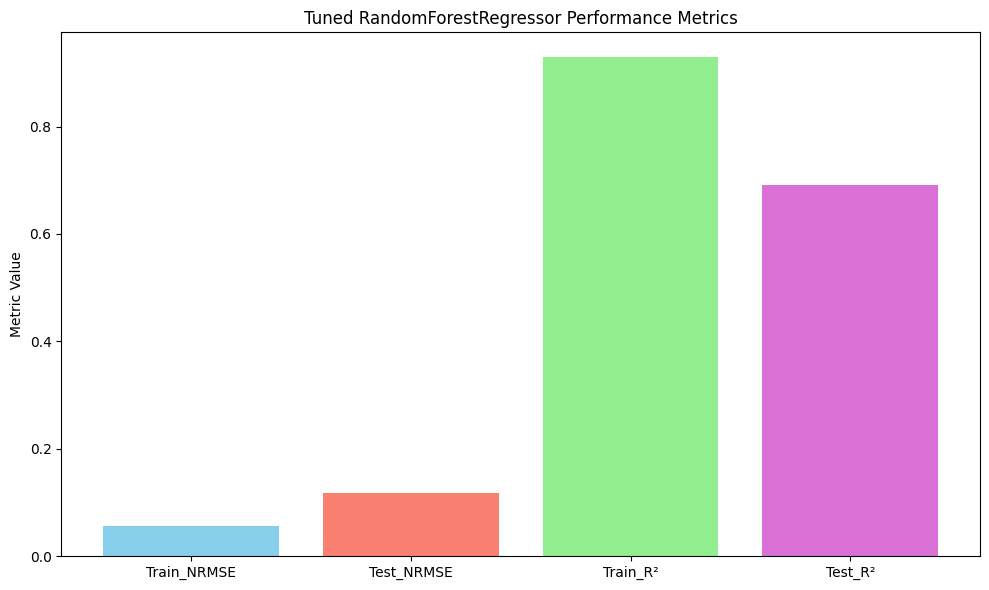

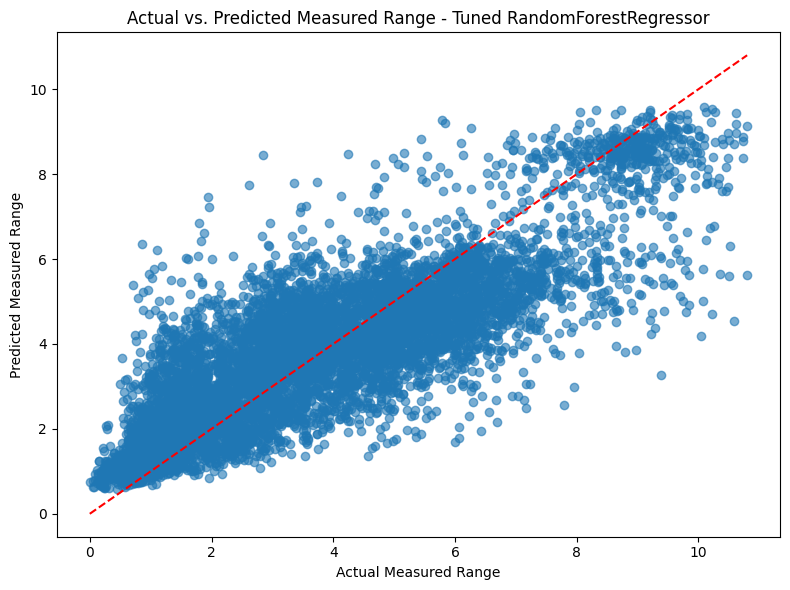

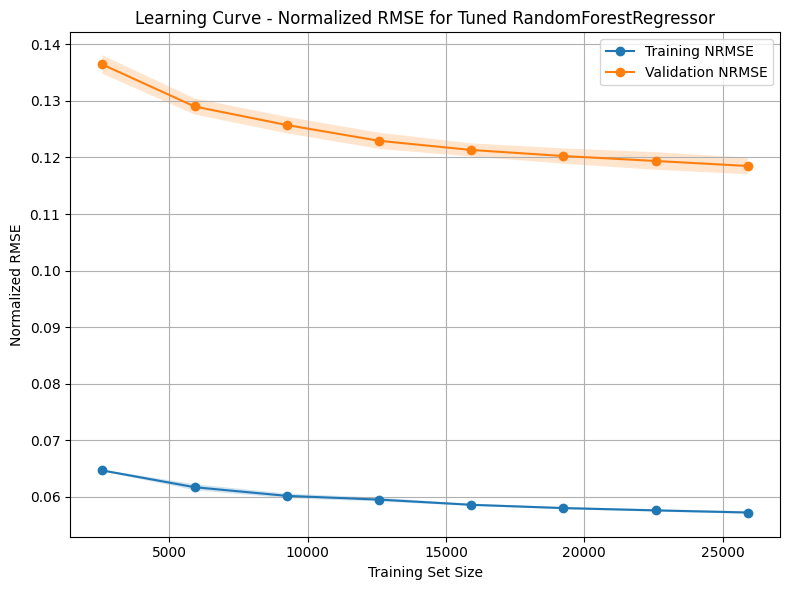

RandomForestRegressor Normalized RMSE Learning Curve Metrics:
Training Set Size: 2590.0 -> Training NRMSE: 0.065 ± 0.000, Validation NRMSE: 0.136 ± 0.002
Training Set Size: 5920.0 -> Training NRMSE: 0.062 ± 0.001, Validation NRMSE: 0.129 ± 0.001
Training Set Size: 9250.0 -> Training NRMSE: 0.060 ± 0.000, Validation NRMSE: 0.126 ± 0.001
Training Set Size: 12580.0 -> Training NRMSE: 0.059 ± 0.000, Validation NRMSE: 0.123 ± 0.001
Training Set Size: 15911.0 -> Training NRMSE: 0.059 ± 0.000, Validation NRMSE: 0.121 ± 0.001
Training Set Size: 19241.0 -> Training NRMSE: 0.058 ± 0.000, Validation NRMSE: 0.120 ± 0.001
Training Set Size: 22571.0 -> Training NRMSE: 0.058 ± 0.000, Validation NRMSE: 0.119 ± 0.002
Training Set Size: 25902.0 -> Training NRMSE: 0.057 ± 0.000, Validation NRMSE: 0.118 ± 0.001


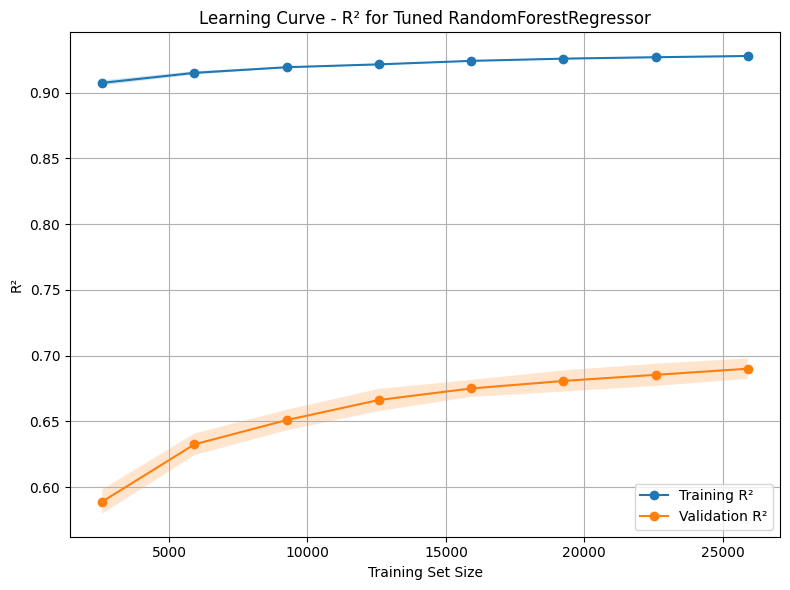


RandomForestRegressor R² Learning Curve Metrics:
Training Set Size: 2590.0 -> Training R²: 0.907 ± 0.002, Validation R²: 0.589 ± 0.009
Training Set Size: 5920.0 -> Training R²: 0.915 ± 0.001, Validation R²: 0.633 ± 0.008
Training Set Size: 9250.0 -> Training R²: 0.919 ± 0.001, Validation R²: 0.651 ± 0.008
Training Set Size: 12580.0 -> Training R²: 0.921 ± 0.000, Validation R²: 0.666 ± 0.008
Training Set Size: 15911.0 -> Training R²: 0.924 ± 0.000, Validation R²: 0.675 ± 0.006
Training Set Size: 19241.0 -> Training R²: 0.926 ± 0.000, Validation R²: 0.681 ± 0.008
Training Set Size: 22571.0 -> Training R²: 0.927 ± 0.001, Validation R²: 0.685 ± 0.008
Training Set Size: 25902.0 -> Training R²: 0.928 ± 0.001, Validation R²: 0.690 ± 0.008


In [197]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import learning_curve
from sklearn.metrics import mean_squared_error, r2_score

# --- Bar Plot of Performance Metrics for RandomForestRegressor ---
# Assuming results_rf is your DataFrame with tuned RandomForestRegressor results,
# with columns: 'Train_NRMSE', 'Test_NRMSE', 'Train_R²', 'Test_R²'
metrics_rf = ['Train_NRMSE', 'Test_NRMSE', 'Train_R²', 'Test_R²']
values_rf = [
    results_rf['Train_NRMSE'].values[0],
    results_rf['Test_NRMSE'].values[0],
    results_rf['Train_R²'].values[0],
    results_rf['Test_R²'].values[0]
]

plt.figure(figsize=(10,6))
plt.bar(metrics_rf, values_rf, color=['skyblue', 'salmon', 'lightgreen', 'orchid'])
plt.title('Tuned RandomForestRegressor Performance Metrics')
plt.ylabel('Metric Value')
plt.tight_layout()
plt.show()


# --- Scatter Plot of Actual vs. Predicted Values for RandomForestRegressor ---
plt.figure(figsize=(8,6))
plt.scatter(y_rf_test, best_rf.predict(X_rf_test), alpha=0.6)
plt.plot([min(y_rf_test), max(y_rf_test)], [min(y_rf_test), max(y_rf_test)], 'r--')
plt.xlabel('Actual Measured Range')
plt.ylabel('Predicted Measured Range')
plt.title('Actual vs. Predicted Measured Range - Tuned RandomForestRegressor')
plt.tight_layout()
plt.show()


# --- Learning Curve for RMSE for RandomForestRegressor ---
train_sizes_rf, train_scores_rmse_rf, valid_scores_rmse_rf = learning_curve(
    best_rf, X_rf_train, y_rf_train, cv=5, scoring='neg_mean_squared_error',
    train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1
)

train_rmse_rf = np.sqrt(-np.mean(train_scores_rmse_rf, axis=1))
valid_rmse_rf = np.sqrt(-np.mean(valid_scores_rmse_rf, axis=1))
train_rmse_rf_std = np.std(np.sqrt(-train_scores_rmse_rf), axis=1)
valid_rmse_rf_std = np.std(np.sqrt(-valid_scores_rmse_rf), axis=1)

# Normalize RMSE using the range of the target variable
y_range = y.max() - y.min()
train_nrmse_rf = train_rmse_rf / y_range
valid_nrmse_rf = valid_rmse_rf / y_range
train_nrmse_rf_std = train_rmse_rf_std / y_range
valid_nrmse_rf_std = valid_rmse_rf_std / y_range

plt.figure(figsize=(8,6))
plt.plot(train_sizes_rf, train_nrmse_rf, 'o-', label='Training NRMSE')
plt.fill_between(train_sizes_rf, train_nrmse_rf - train_nrmse_rf_std, train_nrmse_rf + train_nrmse_rf_std, alpha=0.2)
plt.plot(train_sizes_rf, valid_nrmse_rf, 'o-', label='Validation NRMSE')
plt.fill_between(train_sizes_rf, valid_nrmse_rf - valid_nrmse_rf_std, valid_nrmse_rf + valid_nrmse_rf_std, alpha=0.2)
plt.xlabel('Training Set Size')
plt.ylabel('Normalized RMSE')
plt.title('Learning Curve - Normalized RMSE for Tuned RandomForestRegressor')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("RandomForestRegressor Normalized RMSE Learning Curve Metrics:")
for ts, tr, tr_std, vr, vr_std in zip(train_sizes_rf, train_nrmse_rf, train_nrmse_rf_std, valid_nrmse_rf, valid_nrmse_rf_std):
    print(f"Training Set Size: {ts:.1f} -> Training NRMSE: {tr:.3f} ± {tr_std:.3f}, Validation NRMSE: {vr:.3f} ± {vr_std:.3f}")


# --- Learning Curve for R² for RandomForestRegressor ---
train_sizes_rf, train_scores_r2_rf, valid_scores_r2_rf = learning_curve(
    best_rf, X_rf_train, y_rf_train, cv=5, scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1
)

train_r2_rf_mean = np.mean(train_scores_r2_rf, axis=1)
valid_r2_rf_mean = np.mean(valid_scores_r2_rf, axis=1)
train_r2_rf_std = np.std(train_scores_r2_rf, axis=1)
valid_r2_rf_std = np.std(valid_scores_r2_rf, axis=1)

plt.figure(figsize=(8,6))
plt.plot(train_sizes_rf, train_r2_rf_mean, 'o-', label='Training R²')
plt.fill_between(train_sizes_rf, train_r2_rf_mean - train_r2_rf_std, train_r2_rf_mean + train_r2_rf_std, alpha=0.2)
plt.plot(train_sizes_rf, valid_r2_rf_mean, 'o-', label='Validation R²')
plt.fill_between(train_sizes_rf, valid_r2_rf_mean - valid_r2_rf_std, valid_r2_rf_mean + valid_r2_rf_std, alpha=0.2)
plt.xlabel('Training Set Size')
plt.ylabel('R²')
plt.title('Learning Curve - R² for Tuned RandomForestRegressor')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("\nRandomForestRegressor R² Learning Curve Metrics:")
for ts, tr2, tr2_std, vr2, vr2_std in zip(train_sizes_rf, train_r2_rf_mean, train_r2_rf_std, valid_r2_rf_mean, valid_r2_rf_std):
    print(f"Training Set Size: {ts:.1f} -> Training R²: {tr2:.3f} ± {tr2_std:.3f}, Validation R²: {vr2:.3f} ± {vr2_std:.3f}")


### <font color='red'>LightGBM</font>

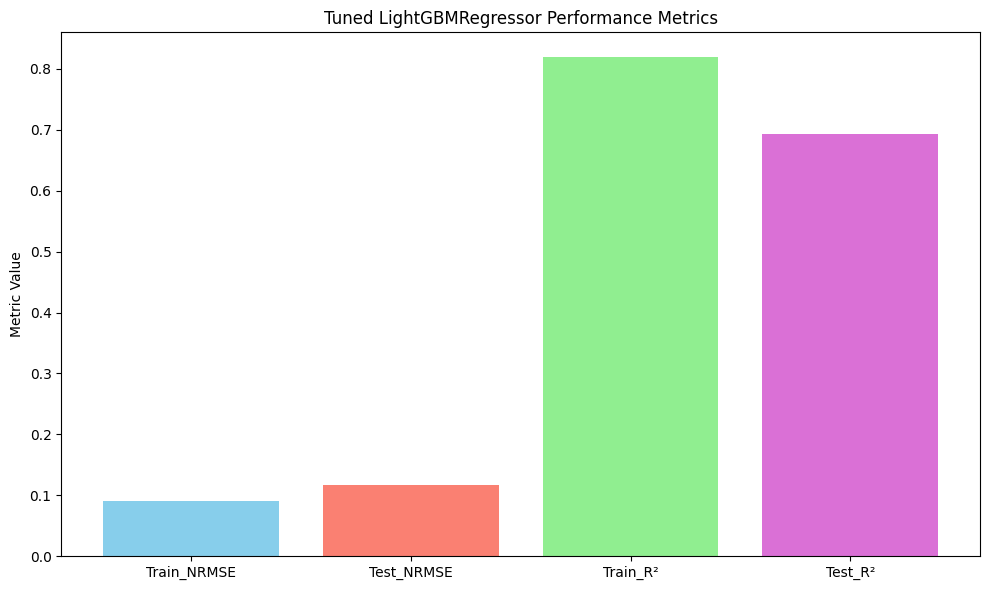

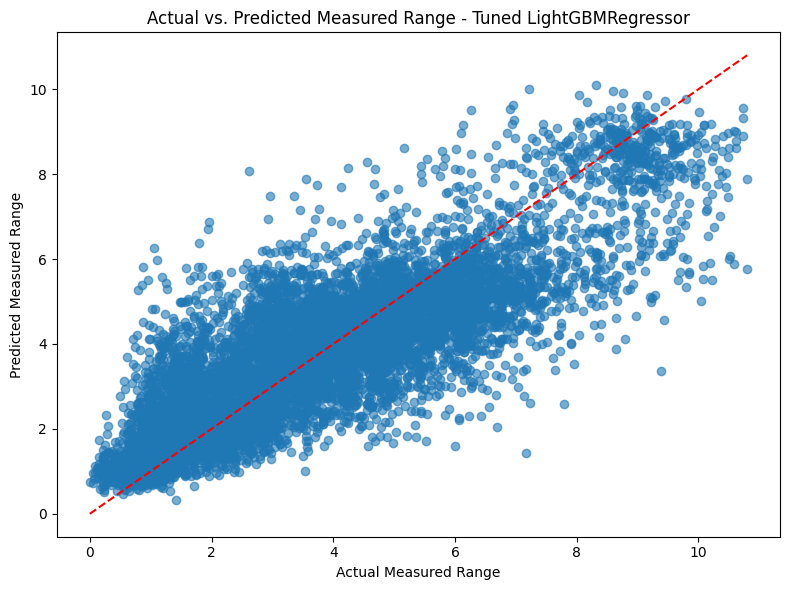

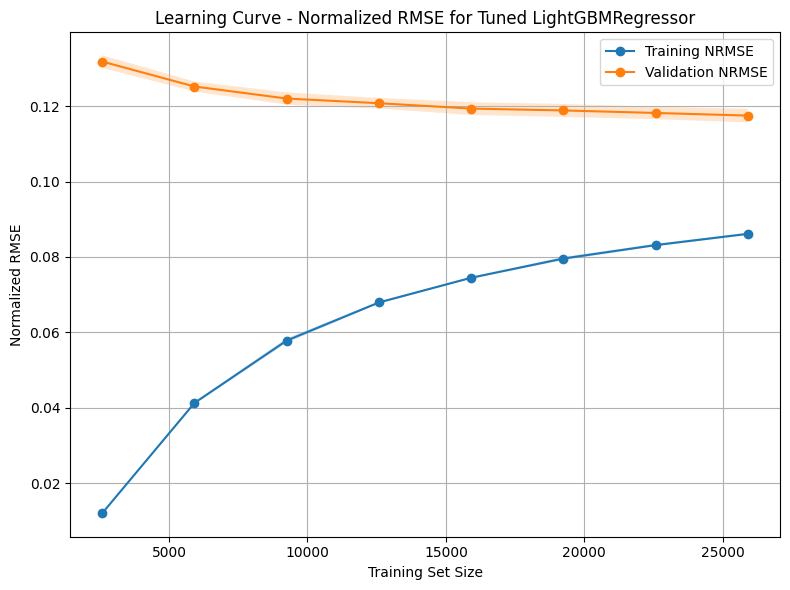

LightGBMRegressor Normalized RMSE Learning Curve Metrics:
Training Set Size: 2590.0 -> Training NRMSE: 0.012 ± 0.000, Validation NRMSE: 0.132 ± 0.002
Training Set Size: 5920.0 -> Training NRMSE: 0.041 ± 0.000, Validation NRMSE: 0.125 ± 0.001
Training Set Size: 9250.0 -> Training NRMSE: 0.058 ± 0.001, Validation NRMSE: 0.122 ± 0.002
Training Set Size: 12580.0 -> Training NRMSE: 0.068 ± 0.000, Validation NRMSE: 0.121 ± 0.001
Training Set Size: 15911.0 -> Training NRMSE: 0.074 ± 0.000, Validation NRMSE: 0.119 ± 0.002
Training Set Size: 19241.0 -> Training NRMSE: 0.080 ± 0.000, Validation NRMSE: 0.119 ± 0.002
Training Set Size: 22571.0 -> Training NRMSE: 0.083 ± 0.000, Validation NRMSE: 0.118 ± 0.002
Training Set Size: 25902.0 -> Training NRMSE: 0.086 ± 0.000, Validation NRMSE: 0.117 ± 0.002


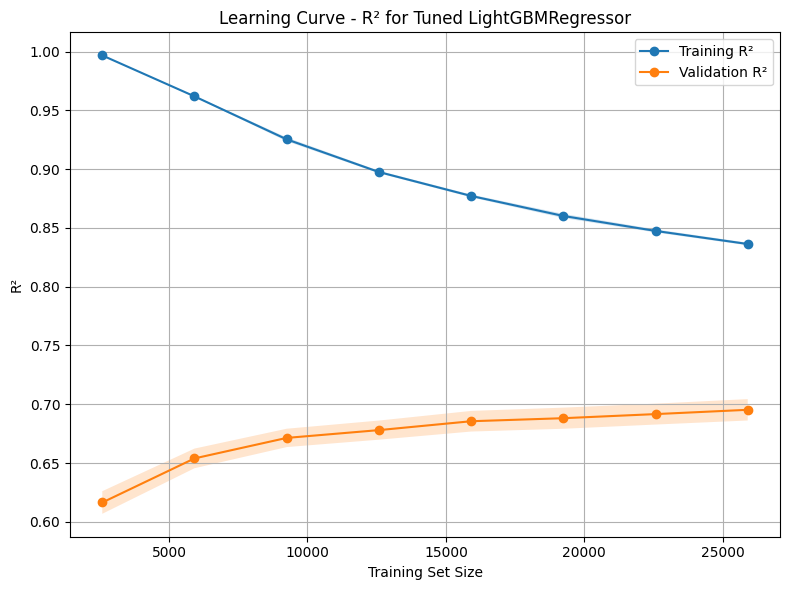


LightGBMRegressor R² Learning Curve Metrics:
Training Set Size: 2590.0 -> Training R²: 0.997 ± 0.000, Validation R²: 0.616 ± 0.010
Training Set Size: 5920.0 -> Training R²: 0.962 ± 0.001, Validation R²: 0.654 ± 0.008
Training Set Size: 9250.0 -> Training R²: 0.925 ± 0.002, Validation R²: 0.671 ± 0.008
Training Set Size: 12580.0 -> Training R²: 0.898 ± 0.001, Validation R²: 0.678 ± 0.008
Training Set Size: 15911.0 -> Training R²: 0.877 ± 0.001, Validation R²: 0.686 ± 0.009
Training Set Size: 19241.0 -> Training R²: 0.860 ± 0.002, Validation R²: 0.688 ± 0.009
Training Set Size: 22571.0 -> Training R²: 0.847 ± 0.001, Validation R²: 0.692 ± 0.009
Training Set Size: 25902.0 -> Training R²: 0.836 ± 0.001, Validation R²: 0.695 ± 0.009


In [196]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import learning_curve
from sklearn.metrics import mean_squared_error, r2_score

# --- Bar Plot of Performance Metrics for LightGBMRegressor ---
# Assuming results_lgb is your DataFrame with tuned LightGBMRegressor results,
# with columns: 'Train_NRMSE', 'Test_NRMSE', 'Train_R²', 'Test_R²'
metrics_lgb = ['Train_NRMSE', 'Test_NRMSE', 'Train_R²', 'Test_R²']
values_lgb = [
    results_lgb['Train_NRMSE'].values[0],
    results_lgb['Test_NRMSE'].values[0],
    results_lgb['Train_R²'].values[0],
    results_lgb['Test_R²'].values[0]
]

plt.figure(figsize=(10,6))
plt.bar(metrics_lgb, values_lgb, color=['skyblue', 'salmon', 'lightgreen', 'orchid'])
plt.title('Tuned LightGBMRegressor Performance Metrics')
plt.ylabel('Metric Value')
plt.tight_layout()
plt.show()


# --- Scatter Plot of Actual vs. Predicted Values for LightGBMRegressor ---
plt.figure(figsize=(8,6))
plt.scatter(y_lgb_test, best_lgb.predict(X_lgb_test), alpha=0.6)
plt.plot([min(y_lgb_test), max(y_lgb_test)], [min(y_lgb_test), max(y_lgb_test)], 'r--')
plt.xlabel('Actual Measured Range')
plt.ylabel('Predicted Measured Range')
plt.title('Actual vs. Predicted Measured Range - Tuned LightGBMRegressor')
plt.tight_layout()
plt.show()


# --- Learning Curve for RMSE for LightGBMRegressor ---
train_sizes_lgb, train_scores_lgb, valid_scores_lgb = learning_curve(
    best_lgb, X_lgb_train, y_lgb_train, cv=5, scoring='neg_mean_squared_error',
    train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1
)

# Convert negative MSE to RMSE
train_rmse_lgb = np.sqrt(-np.mean(train_scores_lgb, axis=1))
valid_rmse_lgb = np.sqrt(-np.mean(valid_scores_lgb, axis=1))
train_rmse_lgb_std = np.std(np.sqrt(-train_scores_lgb), axis=1)
valid_rmse_lgb_std = np.std(np.sqrt(-valid_scores_lgb), axis=1)

# Normalize RMSE using the range of the target variable
y_range = y.max() - y.min()
train_nrmse_lgb = train_rmse_lgb / y_range
valid_nrmse_lgb = valid_rmse_lgb / y_range
train_nrmse_lgb_std = train_rmse_lgb_std / y_range
valid_nrmse_lgb_std = valid_rmse_lgb_std / y_range

plt.figure(figsize=(8,6))
plt.plot(train_sizes_lgb, train_nrmse_lgb, 'o-', label='Training NRMSE')
plt.fill_between(train_sizes_lgb, train_nrmse_lgb - train_nrmse_lgb_std, train_nrmse_lgb + train_nrmse_lgb_std, alpha=0.2)
plt.plot(train_sizes_lgb, valid_nrmse_lgb, 'o-', label='Validation NRMSE')
plt.fill_between(train_sizes_lgb, valid_nrmse_lgb - valid_nrmse_lgb_std, valid_nrmse_lgb + valid_nrmse_lgb_std, alpha=0.2)
plt.xlabel('Training Set Size')
plt.ylabel('Normalized RMSE')
plt.title('Learning Curve - Normalized RMSE for Tuned LightGBMRegressor')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("LightGBMRegressor Normalized RMSE Learning Curve Metrics:")
for ts, tr, tr_std, vr, vr_std in zip(train_sizes_lgb, train_nrmse_lgb, train_nrmse_lgb_std, valid_nrmse_lgb, valid_nrmse_lgb_std):
    print(f"Training Set Size: {ts:.1f} -> Training NRMSE: {tr:.3f} ± {tr_std:.3f}, Validation NRMSE: {vr:.3f} ± {vr_std:.3f}")


# --- Learning Curve for R² for LightGBMRegressor ---
train_sizes_lgb, train_scores_r2_lgb, valid_scores_r2_lgb = learning_curve(
    best_lgb, X_lgb_train, y_lgb_train, cv=5, scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1
)

train_r2_lgb_mean = np.mean(train_scores_r2_lgb, axis=1)
valid_r2_lgb_mean = np.mean(valid_scores_r2_lgb, axis=1)
train_r2_lgb_std = np.std(train_scores_r2_lgb, axis=1)
valid_r2_lgb_std = np.std(valid_scores_r2_lgb, axis=1)

plt.figure(figsize=(8,6))
plt.plot(train_sizes_lgb, train_r2_lgb_mean, 'o-', label='Training R²')
plt.fill_between(train_sizes_lgb, train_r2_lgb_mean - train_r2_lgb_std, train_r2_lgb_mean + train_r2_lgb_std, alpha=0.2)
plt.plot(train_sizes_lgb, valid_r2_lgb_mean, 'o-', label='Validation R²')
plt.fill_between(train_sizes_lgb, valid_r2_lgb_mean - valid_r2_lgb_std, valid_r2_lgb_mean + valid_r2_lgb_std, alpha=0.2)
plt.xlabel('Training Set Size')
plt.ylabel('R²')
plt.title('Learning Curve - R² for Tuned LightGBMRegressor')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("\nLightGBMRegressor R² Learning Curve Metrics:")
for ts, tr2, tr2_std, vr2, vr2_std in zip(train_sizes_lgb, train_r2_lgb_mean, train_r2_lgb_std, valid_r2_lgb_mean, valid_r2_lgb_std):
    print(f"Training Set Size: {ts:.1f} -> Training R²: {tr2:.3f} ± {tr2_std:.3f}, Validation R²: {vr2:.3f} ± {vr2_std:.3f}")


### <font color='red'>MLP</font>

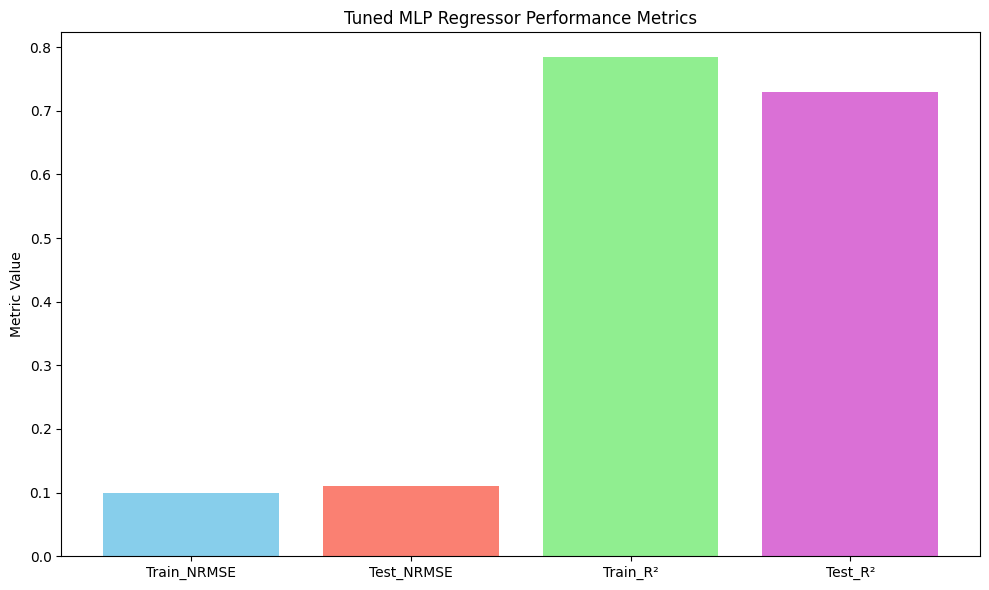

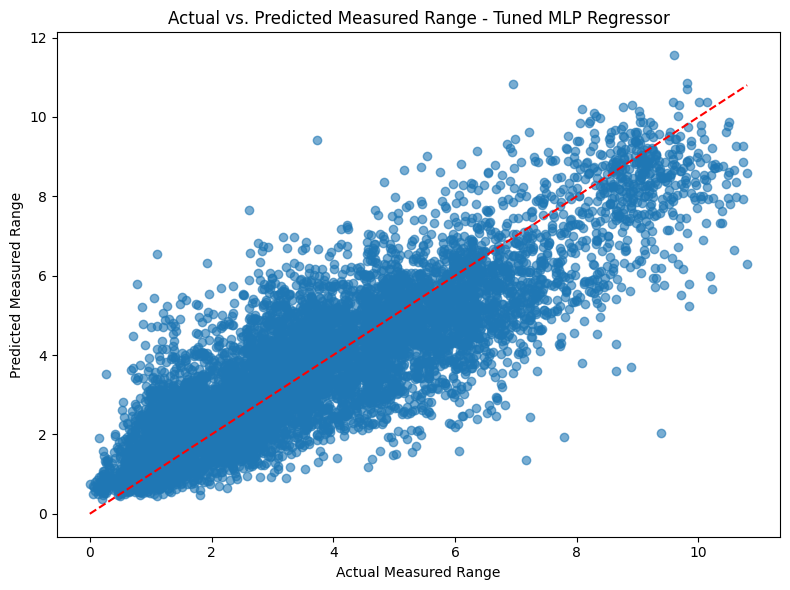

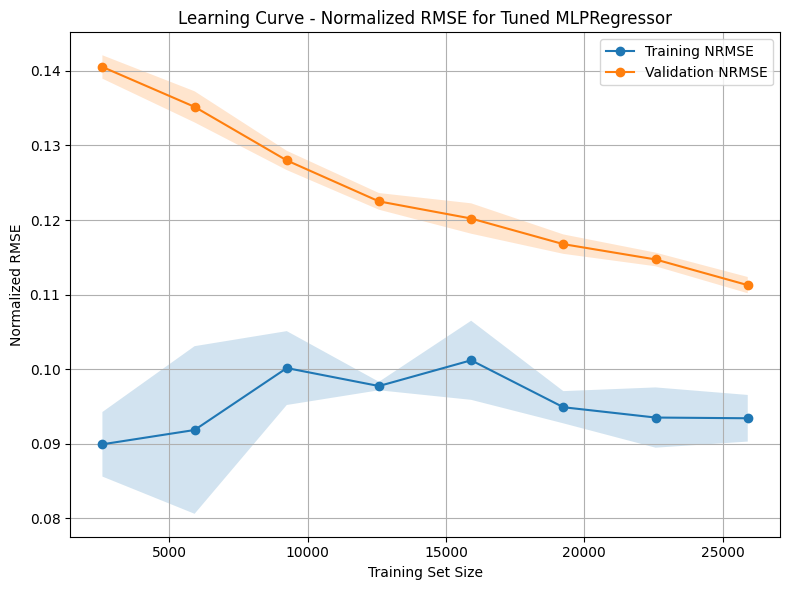

Normalized RMSE Learning Curve Metrics:
Training Set Size: 2590.0 -> Training NRMSE: 0.090 ± 0.004, Validation NRMSE: 0.141 ± 0.002
Training Set Size: 5920.0 -> Training NRMSE: 0.092 ± 0.011, Validation NRMSE: 0.135 ± 0.002
Training Set Size: 9250.0 -> Training NRMSE: 0.100 ± 0.005, Validation NRMSE: 0.128 ± 0.001
Training Set Size: 12580.0 -> Training NRMSE: 0.098 ± 0.001, Validation NRMSE: 0.123 ± 0.001
Training Set Size: 15911.0 -> Training NRMSE: 0.101 ± 0.005, Validation NRMSE: 0.120 ± 0.002
Training Set Size: 19241.0 -> Training NRMSE: 0.095 ± 0.002, Validation NRMSE: 0.117 ± 0.001
Training Set Size: 22571.0 -> Training NRMSE: 0.094 ± 0.004, Validation NRMSE: 0.115 ± 0.001
Training Set Size: 25902.0 -> Training NRMSE: 0.093 ± 0.003, Validation NRMSE: 0.111 ± 0.001


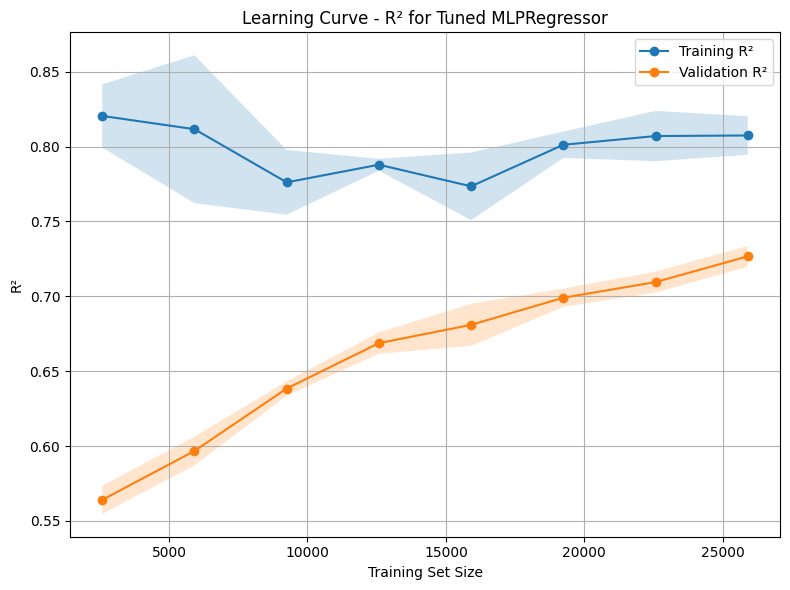


R² Learning Curve Metrics:
Training Set Size: 2590.0 -> Training R²: 0.820 ± 0.021, Validation R²: 0.564 ± 0.009
Training Set Size: 5920.0 -> Training R²: 0.812 ± 0.049, Validation R²: 0.597 ± 0.010
Training Set Size: 9250.0 -> Training R²: 0.776 ± 0.022, Validation R²: 0.638 ± 0.005
Training Set Size: 12580.0 -> Training R²: 0.788 ± 0.004, Validation R²: 0.669 ± 0.007
Training Set Size: 15911.0 -> Training R²: 0.773 ± 0.023, Validation R²: 0.681 ± 0.014
Training Set Size: 19241.0 -> Training R²: 0.801 ± 0.009, Validation R²: 0.699 ± 0.006
Training Set Size: 22571.0 -> Training R²: 0.807 ± 0.017, Validation R²: 0.710 ± 0.007
Training Set Size: 25902.0 -> Training R²: 0.807 ± 0.013, Validation R²: 0.727 ± 0.007


In [195]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import learning_curve

# ----- Bar Plot of Performance Metrics -----
# Assuming results_mlp is your DataFrame with tuned MLP results,
# with columns: 'Train_NRMSE', 'Test_NRMSE', 'Train_R²', 'Test_R²'
metrics = ['Train_NRMSE', 'Test_NRMSE', 'Train_R²', 'Test_R²']
values = [
    results_mlp['Train_NRMSE'].values[0],
    results_mlp['Test_NRMSE'].values[0],
    results_mlp['Train_R²'].values[0],
    results_mlp['Test_R²'].values[0]
]

plt.figure(figsize=(10,6))
plt.bar(metrics, values, color=['skyblue', 'salmon', 'lightgreen', 'orchid'])
plt.title('Tuned MLP Regressor Performance Metrics')
plt.ylabel('Metric Value')
plt.tight_layout()
plt.show()


# ----- Scatter Plot of Actual vs. Predicted Values -----
plt.figure(figsize=(8,6))
plt.scatter(y_mlp_test, y_mlp_test_pred, alpha=0.6)
plt.plot([min(y_mlp_test), max(y_mlp_test)], [min(y_mlp_test), max(y_mlp_test)], 'r--')
plt.xlabel('Actual Measured Range')
plt.ylabel('Predicted Measured Range')
plt.title('Actual vs. Predicted Measured Range - Tuned MLP Regressor')
plt.tight_layout()
plt.show()


# ----- Learning Curve for Normalized RMSE -----
# Generate learning curve using 5-Fold CV on training set
train_sizes, train_scores_rmse, valid_scores_rmse = learning_curve(
    best_mlp, X_mlp_train, y_mlp_train, cv=5, scoring='neg_mean_squared_error',
    train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1
)

# Convert negative MSE to RMSE
train_rmse = np.sqrt(-np.mean(train_scores_rmse, axis=1))
valid_rmse = np.sqrt(-np.mean(valid_scores_rmse, axis=1))

# Compute standard deviations for RMSE
train_rmse_std = np.std(np.sqrt(-train_scores_rmse), axis=1)
valid_rmse_std = np.std(np.sqrt(-valid_scores_rmse), axis=1)

# Compute normalized RMSE using the range of the target variable
y_range = y.max() - y.min()
train_nrmse = train_rmse / y_range
valid_nrmse = valid_rmse / y_range
train_nrmse_std = train_rmse_std / y_range
valid_nrmse_std = valid_rmse_std / y_range

plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_nrmse, 'o-', label='Training NRMSE')
plt.fill_between(train_sizes, train_nrmse - train_nrmse_std, train_nrmse + train_nrmse_std, alpha=0.2)
plt.plot(train_sizes, valid_nrmse, 'o-', label='Validation NRMSE')
plt.fill_between(train_sizes, valid_nrmse - valid_nrmse_std, valid_nrmse + valid_nrmse_std, alpha=0.2)
plt.xlabel('Training Set Size')
plt.ylabel('Normalized RMSE')
plt.title('Learning Curve - Normalized RMSE for Tuned MLPRegressor')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("Normalized RMSE Learning Curve Metrics:")
for ts, tnrmse, tnrmse_std, vnrmse, vnrmse_std in zip(train_sizes, train_nrmse, train_nrmse_std, valid_nrmse, valid_nrmse_std):
    print(f"Training Set Size: {ts:.1f} -> Training NRMSE: {tnrmse:.3f} ± {tnrmse_std:.3f}, Validation NRMSE: {vnrmse:.3f} ± {vnrmse_std:.3f}")


# ----- Learning Curve for R² -----
train_sizes, train_scores_r2, valid_scores_r2 = learning_curve(
    best_mlp, X_mlp_train, y_mlp_train, cv=5, scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1
)

train_r2_mean = np.mean(train_scores_r2, axis=1)
valid_r2_mean = np.mean(valid_scores_r2, axis=1)
train_r2_std = np.std(train_scores_r2, axis=1)
valid_r2_std = np.std(valid_scores_r2, axis=1)

plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_r2_mean, 'o-', label='Training R²')
plt.fill_between(train_sizes, train_r2_mean - train_r2_std, train_r2_mean + train_r2_std, alpha=0.2)
plt.plot(train_sizes, valid_r2_mean, 'o-', label='Validation R²')
plt.fill_between(train_sizes, valid_r2_mean - valid_r2_std, valid_r2_mean + valid_r2_std, alpha=0.2)
plt.xlabel('Training Set Size')
plt.ylabel('R²')
plt.title('Learning Curve - R² for Tuned MLPRegressor')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("\nR² Learning Curve Metrics:")
for ts, tr2, tr2_std, vr2, vr2_std in zip(train_sizes, train_r2_mean, train_r2_std, valid_r2_mean, valid_r2_std):
    print(f"Training Set Size: {ts:.1f} -> Training R²: {tr2:.3f} ± {tr2_std:.3f}, Validation R²: {vr2:.3f} ± {vr2_std:.3f}")


### Analysis Conclusion

Based on our comprehensive comparison of the tuned regression models, the tuned **MLP Regressor** emerges as the best candidate for our indoor localization task. Our evaluation consisted of three stages: the base model, the model after applying feature importance and PCA, and finally the tuned model using GridSearchCV. For regression, we focused on metrics such as normalized RMSE (NRMSE) and R², which respectively measure the average prediction error relative to the target’s range and the proportion of variance explained by the model.

- **Random ForestRegressor:**  
  At a training set size of 25,902, the tuned Random Forest Regressor exhibits a training NRMSE of **0.057 ± 0.000** and a validation NRMSE of **0.118 ± 0.001**. Its training R² is **0.928 ± 0.001**, while its validation R² is **0.690 ± 0.008**. Although it achieves an exceptionally tight fit on the training data, the scatter plot indicates that for higher measured range values the predictions tend to systematically fall below the actual values, suggesting underestimation in the upper range.

- **LightGBM Regressor:**  
  The tuned LightGBM Regressor shows a training NRMSE of **0.086 ± 0.000** and a validation NRMSE of **0.117 ± 0.002**, with a training R² of **0.836 ± 0.001** and a validation R² of **0.695 ± 0.009**. This model generalizes slightly better than Random Forest Regressor, as reflected by its higher test R², but it still exhibits a tendency to underestimate higher-range values.

- **MLP Regressor:**  
  The tuned MLP Regressor records a training NRMSE of **0.093 ± 0.003** and a validation NRMSE of **0.111 ± 0.001**, with a training R² of **0.807 ± 0.013** and a validation R² of **0.727 ± 0.007**. Although its training error is marginally higher than that of RandomForestRegressor and LightGBM Regressor, its test performance is notably better: the MLP Regressor achieves the highest validation R² (0.727) and the lowest validation NRMSE (0.111). Moreover, the scatter plot for the MLP Regressor shows a more balanced distribution of predictions around the diagonal at higher measured ranges, with points distributed both above and below the ideal line rather than clustering predominantly below it. This indicates that the MLP Regressor better captures the variability in the upper range, reducing bias and improving overall generalization.

Additionally, the learning curves for all models—generated via 5-fold cross-validation—demonstrate that as the training set size increases, the validation metrics stabilize and converge. This indicates that adding more data reduces overfitting and enhances model performance.

Overall, despite the slightly higher training error, the tuned **MLP Regressor**’s superior validation R² and more balanced predictions in the higher range make it the best model for our regression task. Its ability to generalize effectively to unseen data, as evidenced by both the learning curves and scatter plot analyses, supports its selection for our indoor localization solution.
